14:37:02 │ INFO │ Cache found → C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\ICNT_14Ring_Cascade_UniDir_neff_sweep_V2.h5


lumapi imported from:
  C:\Program Files\Lumerical\v202\api\python\lumapi.py

  Data directory : C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep
  HDF5 output    : C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\ICNT_14Ring_Cascade_UniDir_neff_sweep_V2.h5
  Figures dir    : C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\figures
  INTERCONNECT 14-Ring Cascade — Parameter Summary  [UNIDIRECTIONAL]
   Ring     R [µm]    λ_res [nm]    neff_TE     ng_TE     κ²_in     κ²_dr     Loss
  ────────────────────────────────────────────────────────────────────
      1    19.0021     1550.0000   1.609803  2.020543  0.145778  0.143402    101.0  ← swept
      2    19.1818     1550.0000   1.633303  1.991101  0.145072  0.142672    101.0
      3    19.1934     1550.7692   1.633

14:37:02 │ INFO │ Cached: 200/200  |  Remaining: 0
14:37:02 │ INFO │ All sweep points cached — skipping INTERCONNECT launch.



  Sweep complete — 200 / 200 pts computed
  T_port1_dB     shape : (200, 1000)      (ONA in1 / RING_1 through)
  T_port2_dB     shape : (200, 1000)      (ONA in2 / RING_14 through)
  opm_power_dBm  shape : (200, 13)   (13 OPMs = RING_2..14 drops)
  opm_spectrum_W shape : (200, 13, 1000)
  HDF5                 : C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\ICNT_14Ring_Cascade_UniDir_neff_sweep_V2.h5


14:37:05 │ INFO │ Saved → transmittance_port1_200curves.png/pdf
14:37:08 │ INFO │ Saved → transmittance_port2_200curves.png/pdf
14:37:09 │ INFO │ Saved → opm_power_vs_neff_all.png/pdf
14:37:23 │ INFO │ Saved → opm13_spectrum_heatmap.png/pdf
14:37:35 │ INFO │ Saved → opm1_spectrum_heatmap.png/pdf
C:\Users\jero0\AppData\Local\Temp\ipykernel_2716\484393809.py:1247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
14:41:04 │ INFO │ Saved → all_opm_heatmaps_grid.png/pdf
14:41:05 │ INFO │ Saved → resonance_tracking_port1.png/pdf
14:41:05 │ INFO │ Resonance sensitivity (port 1): 772.5621 nm/RIU


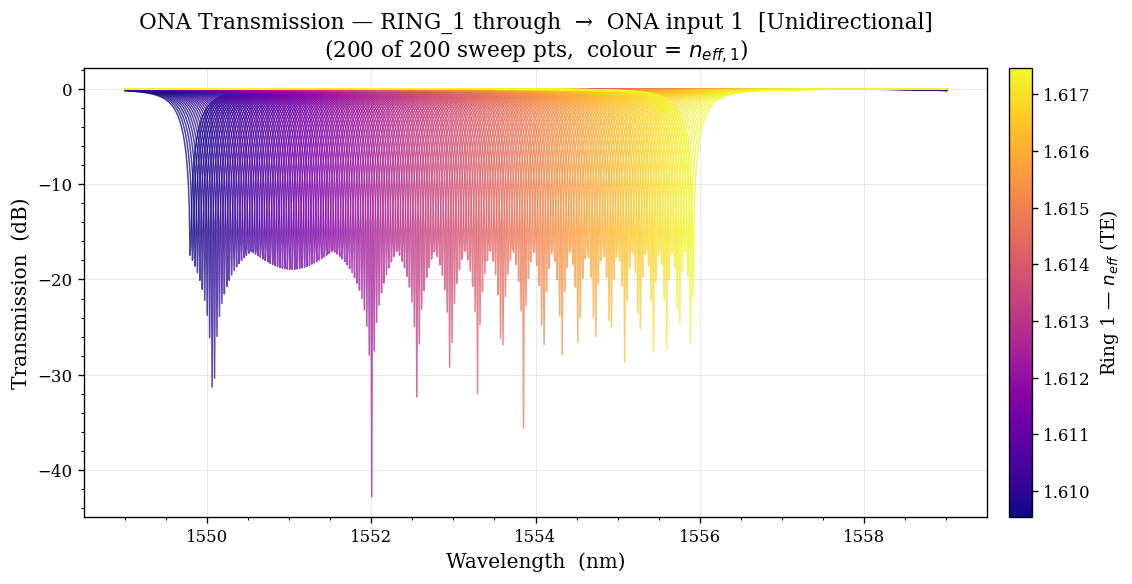

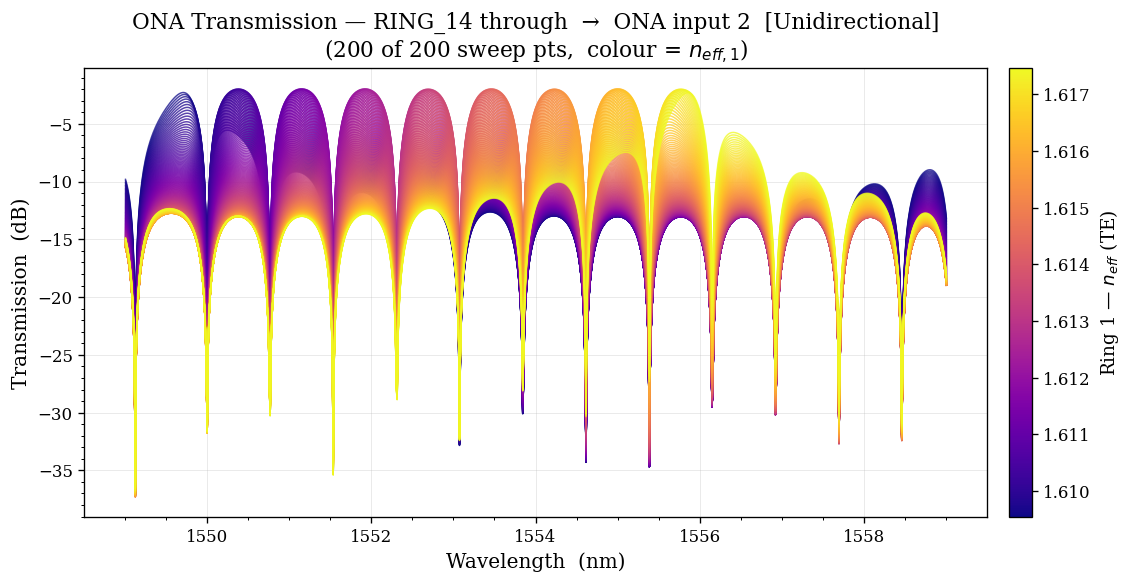

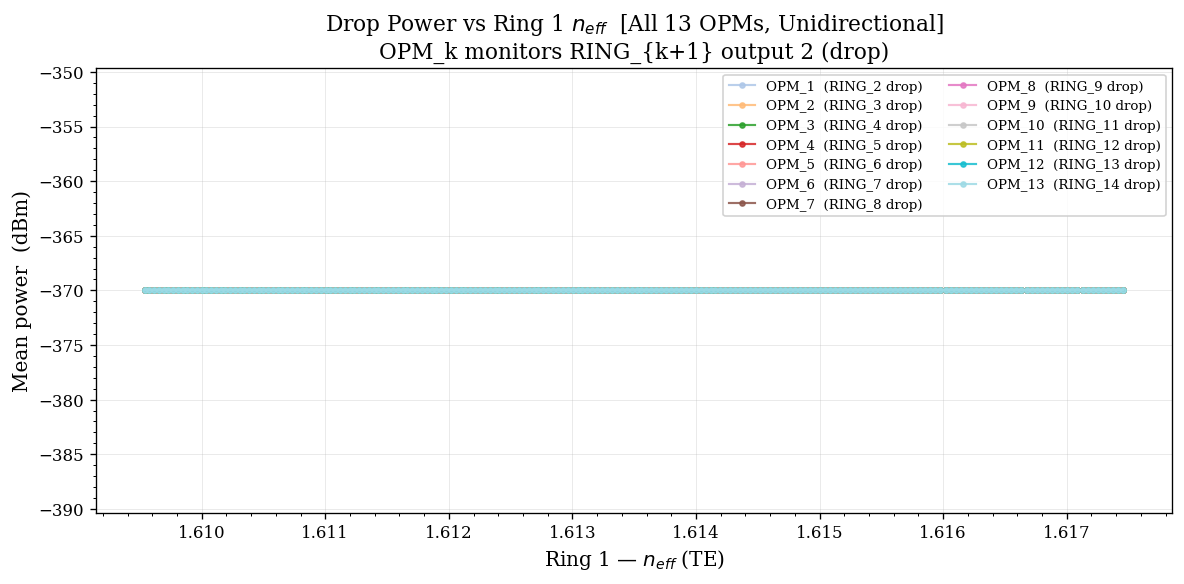

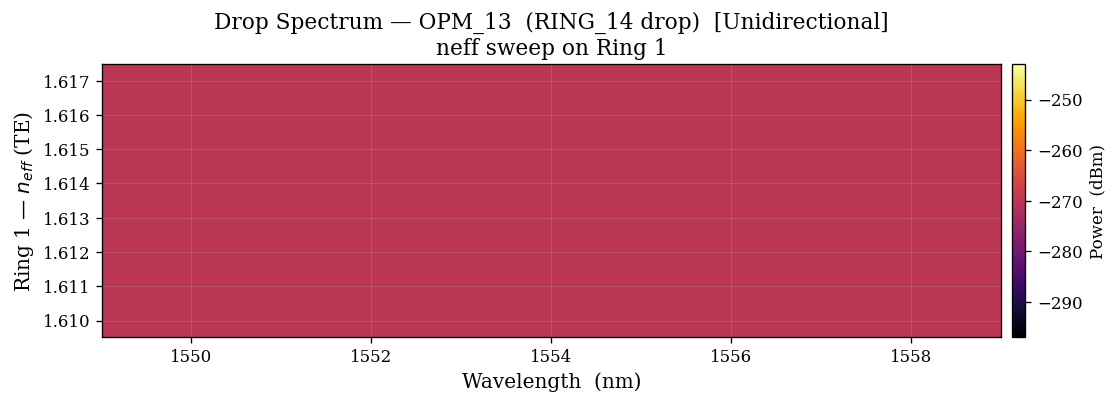

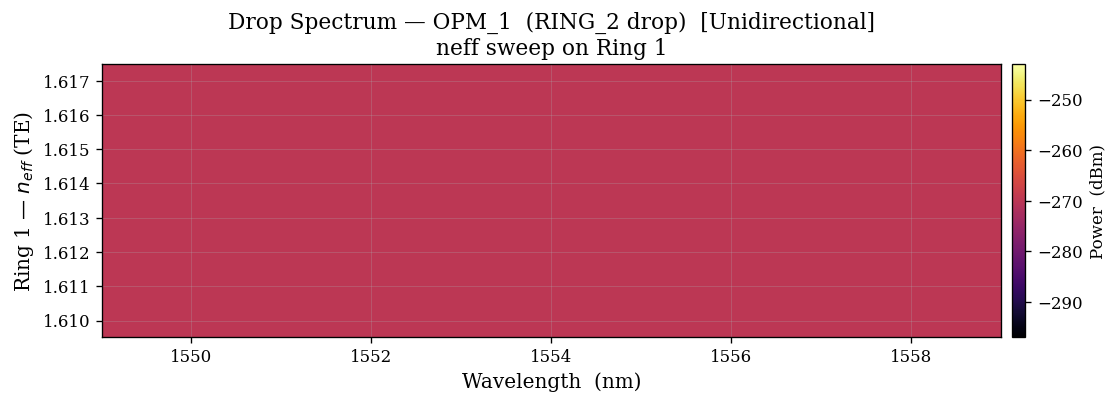

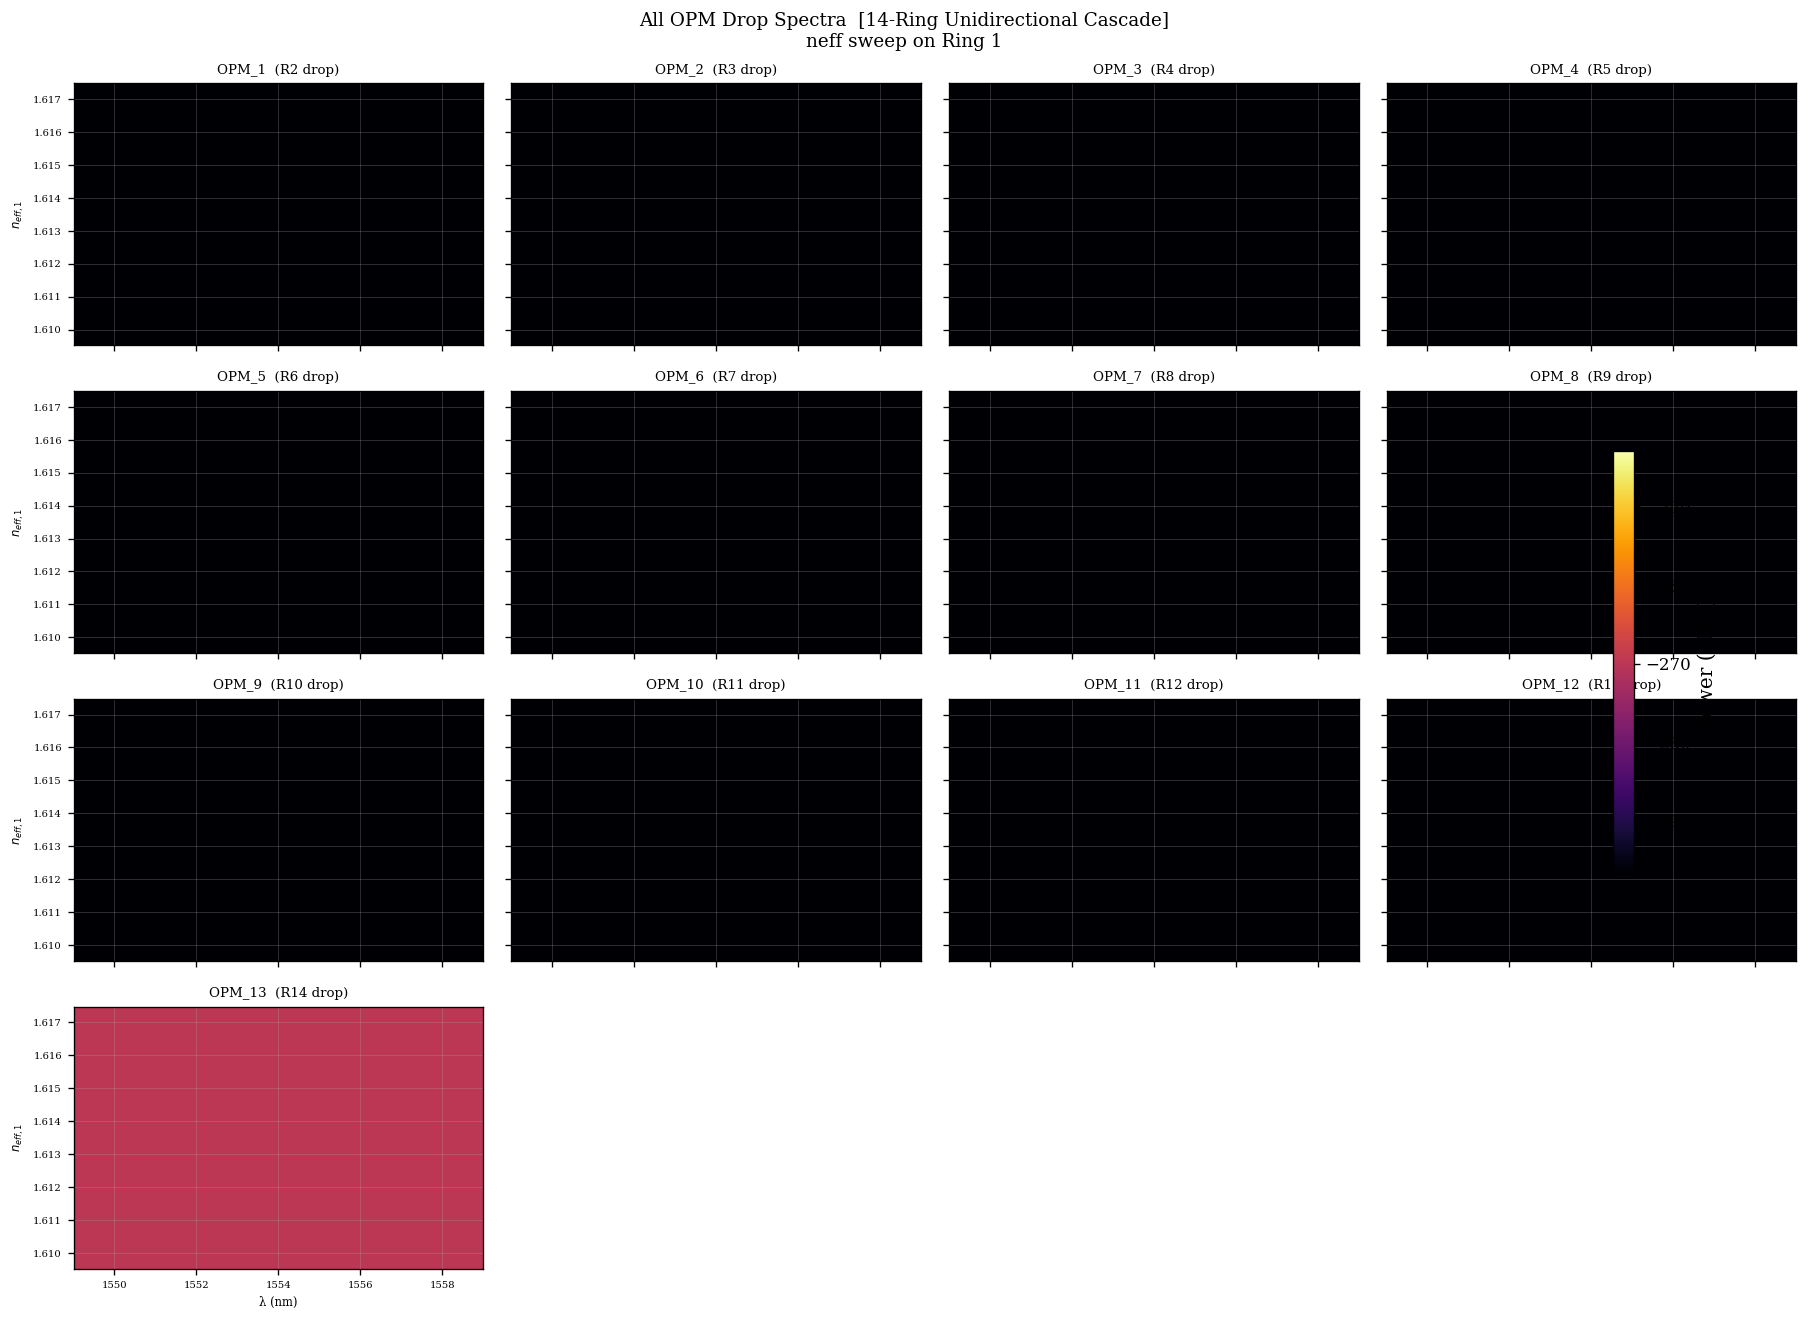

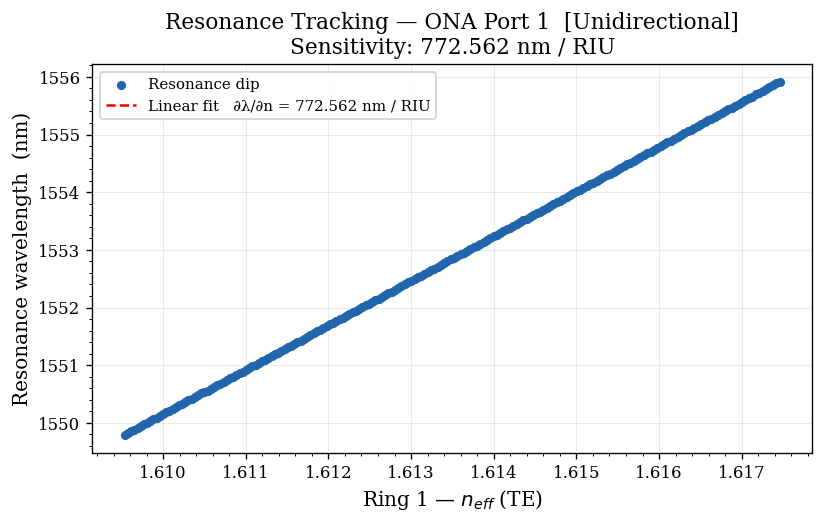


  Figures → C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\figures
  HDF5    → C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\ICNT_14Ring_Cascade_UniDir_neff_sweep_V2.h5


In [1]:
import math

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports · lumapi setup · Logging · I/O paths                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys, os, platform, time, logging
from pathlib import Path
from datetime import datetime
from typing import Optional, Tuple, Dict, Any

import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

LUMERICAL_VERSION = "v202"
if platform.system() == "Windows":
    LUMERICAL_ROOT = rf"C:\Program Files\Lumerical\{LUMERICAL_VERSION}"
    LUMERICAL_API  = rf"{LUMERICAL_ROOT}\api\python"
    LUMERICAL_BIN  = rf"{LUMERICAL_ROOT}\bin"
else:
    LUMERICAL_ROOT = f"/opt/lumerical/{LUMERICAL_VERSION}"
    LUMERICAL_API  = f"{LUMERICAL_ROOT}/api/python"
    LUMERICAL_BIN  = f"{LUMERICAL_ROOT}/bin"

if "lumapi" in sys.modules:
    del sys.modules["lumapi"]
if LUMERICAL_API not in sys.path:
    sys.path.insert(0, LUMERICAL_API)
if platform.system() == "Windows":
    if hasattr(os, "add_dll_directory"):
        os.add_dll_directory(str(LUMERICAL_BIN))
    else:
        os.environ["PATH"] = str(LUMERICAL_BIN) + ";" + os.environ.get("PATH", "")

assert Path(LUMERICAL_API).exists(), f"API path not found: {LUMERICAL_API}"
assert Path(LUMERICAL_BIN).exists(), f"bin path not found: {LUMERICAL_BIN}"

import lumapi
print(f"lumapi imported from:\n  {lumapi.__file__}")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s │ %(levelname)s │ %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("ICNT_Cascade")

VERSION_NAME = "ICNT_14Ring_Cascade_UniDir_neff_sweep_V2"
PROJECT_DIR  = Path.cwd()
DATA_DIR     = PROJECT_DIR / "data_ICNT_cascade_ring_sweep"
DATA_DIR.mkdir(parents=True, exist_ok=True)
HDF5_PATH    = DATA_DIR / f"{VERSION_NAME}.h5"
FIGURES_DIR  = DATA_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n  Data directory : {DATA_DIR}")
print(f"  HDF5 output    : {HDF5_PATH}")
print(f"  Figures dir    : {FIGURES_DIR}")

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 1
# ═════════════════════════════════════════════════════════════════════════════


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Simulation parameters                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

N_RINGS = 14

RING_RADIUS_M = np.array([
    19.0021e-6, 19.1818e-6, 19.1934e-6, 19.2051e-6,
    19.2168e-6, 19.2284e-6, 19.2401e-6, 19.2517e-6,
    19.4158e-6, 19.4275e-6, 19.4393e-6, 19.4511e-6,
    19.4628e-6, 19.4746e-6,
])
RING_LAMBDA_RES_M = np.array([
    1.5500000e-6, 1.5500000e-6, 1.5507692e-6, 1.5515385e-6,
    1.5523077e-6, 1.5530769e-6, 1.5538462e-6, 1.5546154e-6,
    1.5553846e-6, 1.5561538e-6, 1.5569231e-6, 1.5576923e-6,
    1.5584615e-6, 1.5582308e-6,
])
RING_NEFF_TE = np.array([
    1.609803, 1.633303, 1.633121, 1.632939,
    1.632758, 1.632576, 1.632394, 1.632213,
    1.631974, 1.631792, 1.631611, 1.631430,
    1.631248, 1.631067,
])
RING_NG_TE = np.array([
    2.020543, 1.991101, 1.990956, 1.990808,
    1.990659, 1.990509, 1.990356, 1.990203,
    1.990047, 1.989891, 1.989733, 1.989691,
    1.989528, 1.989364,
])
RING_D_TE_PS2_PER_KM = np.zeros(N_RINGS)
RING_D_TM_PS2_PER_KM = np.zeros(N_RINGS)
RING_NEFF_TM         = np.full(N_RINGS, 1.7000)
RING_NG_TM           = np.full(N_RINGS, 2.1000)
RING_KAPPA_INPUT_SQ  = np.array([
    0.145778, 0.145072, 0.145011, 0.144949,
    0.144888, 0.144827, 0.144765, 0.144704,
    0.145696, 0.145634, 0.145572, 0.145518,
    0.145456, 0.145394,
])
RING_KAPPA_DROP_SQ = np.array([
    0.143402, 0.142672, 0.142609, 0.142546,
    0.142484, 0.142420, 0.142357, 0.142294,
    0.143269, 0.143205, 0.143142, 0.143086,
    0.143022, 0.142958,
])
RING_LOSS_DB_PER_M = np.full(N_RINGS, 101.0)
RING_POLARIZATION  = ["TE"] * N_RINGS

ONA_LAMBDA_START_M = 1.549e-6
ONA_LAMBDA_STOP_M  = 1.559e-6
ONA_N_POINTS       = 1000
ONA_POWER_DBM      = 0.0
ONA_N_INPUT_PORTS  = 2          # ONA monitors only RING_1 through and RING_14 through

SWEEP_N_POINTS = 200
# SWEEP_NEFF = np.linspace(1.90, 2.10, SWEEP_N_POINTS)
# SWEEP_NG   = np.linspace(2.20, 2.45, SWEEP_N_POINTS)

SWEEP_NEFF = np.array([
    1.6095387512, 1.6095769971, 1.6096152579, 1.6096535338, 1.6096918246, 1.6097301304, 1.6097684512, 1.6098067871, 1.6098451380, 1.6098835039,
    1.6099218849, 1.6099602810, 1.6099986921, 1.6100371184, 1.6100755597, 1.6101140162, 1.6101524877, 1.6101909744, 1.6102294763, 1.6102679933,
    1.6103065255, 1.6103450728, 1.6103836354, 1.6104222131, 1.6104608060, 1.6104994142, 1.6105380376, 1.6105766762, 1.6106153301, 1.6106539993,
    1.6106926837, 1.6107313835, 1.6107700985, 1.6108088288, 1.6108475745, 1.6108863355, 1.6109251118, 1.6109639035, 1.6110027106, 1.6110415330,
    1.6110803708, 1.6111192240, 1.6111580927, 1.6111969767, 1.6112358762, 1.6112747912, 1.6113137215, 1.6113526674, 1.6113916287, 1.6114306056,
    1.6114695979, 1.6115086057, 1.6115476291, 1.6115866680, 1.6116257225, 1.6116647925, 1.6117038781, 1.6117429792, 1.6117820960, 1.6118212284,
    1.6118603763, 1.6118995400, 1.6119387192, 1.6119779141, 1.6120171247, 1.6120563509, 1.6120955929, 1.6121348505, 1.6121741238, 1.6122134129,
    1.6122527177, 1.6122920382, 1.6123313745, 1.6123707266, 1.6124100945, 1.6124494781, 1.6124888776, 1.6125282928, 1.6125677239, 1.6126071709,
    1.6126466336, 1.6126861123, 1.6127256068, 1.6127651172, 1.6128046436, 1.6128441858, 1.6128837439, 1.6129233180, 1.6129629081, 1.6130025141,
    1.6130421360, 1.6130817740, 1.6131214279, 1.6131610979, 1.6132007839, 1.6132404859, 1.6132802040, 1.6133199381, 1.6133596883, 1.6133994545,
    1.6134392369, 1.6134790354, 1.6135188500, 1.6135586807, 1.6135985276, 1.6136383906, 1.6136782698, 1.6137181652, 1.6137580767, 1.6137980045,
    1.6138379485, 1.6138779087, 1.6139178852, 1.6139578779, 1.6139978869, 1.6140379122, 1.6140779537, 1.6141180116, 1.6141580858, 1.6141981763,
    1.6142382832, 1.6142784064, 1.6143185460, 1.6143587019, 1.6143988743, 1.6144390631, 1.6144792683, 1.6145194899, 1.6145597279, 1.6145999825,
    1.6146402535, 1.6146805410, 1.6147208449, 1.6147611654, 1.6148015024, 1.6148418560, 1.6148822261, 1.6149226127, 1.6149630160, 1.6150034358,
    1.6150438722, 1.6150843252, 1.6151247949, 1.6151652812, 1.6152057842, 1.6152463038, 1.6152868401, 1.6153273931, 1.6153679628, 1.6154085492,
    1.6154491523, 1.6154897722, 1.6155304089, 1.6155710623, 1.6156117325, 1.6156524195, 1.6156931233, 1.6157338439, 1.6157745814, 1.6158153358,
    1.6158561070, 1.6158968950, 1.6159377000, 1.6159785219, 1.6160193607, 1.6160602164, 1.6161010891, 1.6161419787, 1.6161828853, 1.6162238089,
    1.6162647495, 1.6163057071, 1.6163466817, 1.6163876734, 1.6164286821, 1.6164697079, 1.6165107508, 1.6165518108, 1.6165928879, 1.6166339821,
    1.6166750935, 1.6167162220, 1.6167573676, 1.6167985305, 1.6168397106, 1.6168809078, 1.6169221223, 1.6169633540, 1.6170046030, 1.6170458692,
    1.6170871527, 1.6171284535, 1.6171697716, 1.6172111070, 1.6172524598, 1.6172938299, 1.6173352174, 1.6173766222, 1.6174180445, 1.6174594841,
])

SWEEP_NG = np.array([
    2.0218079294, 2.0217699008, 2.0217318512, 2.0216937805, 2.0216556887, 2.0216175759, 2.0215794420, 2.0215412869, 2.0215031108, 2.0214649135,
    2.0214266951, 2.0213884554, 2.0213501947, 2.0213119127, 2.0212736095, 2.0212352850, 2.0211969393, 2.0211585724, 2.0211201842, 2.0210817747,
    2.0210433438, 2.0210048917, 2.0209664182, 2.0209279233, 2.0208894071, 2.0208508695, 2.0208123105, 2.0207737300, 2.0207351281, 2.0206965047,
    2.0206578599, 2.0206191936, 2.0205805057, 2.0205417964, 2.0205030655, 2.0204643130, 2.0204255389, 2.0203867433, 2.0203479260, 2.0203090871,
    2.0202702265, 2.0202313443, 2.0201924404, 2.0201535147, 2.0201145674, 2.0200755983, 2.0200366074, 2.0199975948, 2.0199585603, 2.0199195041,
    2.0198804260, 2.0198413260, 2.0198022042, 2.0197630605, 2.0197238948, 2.0196847073, 2.0196454977, 2.0196062662, 2.0195670127, 2.0195277372,
    2.0194884397, 2.0194491201, 2.0194097784, 2.0193704147, 2.0193310288, 2.0192916208, 2.0192521906, 2.0192127383, 2.0191732638, 2.0191337670,
    2.0190942481, 2.0190547068, 2.0190151433, 2.0189755575, 2.0189359493, 2.0188963188, 2.0188566660, 2.0188169907, 2.0187772931, 2.0187375730,
    2.0186978305, 2.0186580655, 2.0186182780, 2.0185784679, 2.0185386354, 2.0184987803, 2.0184589025, 2.0184190022, 2.0183790793, 2.0183391337,
    2.0182991654, 2.0182591744, 2.0182191607, 2.0181791242, 2.0181390650, 2.0180989829, 2.0180588781, 2.0180187504, 2.0179785999, 2.0179384264,
    2.0178982301, 2.0178580108, 2.0178177685, 2.0177775033, 2.0177372150, 2.0176969037, 2.0176565693, 2.0176162119, 2.0175758313, 2.0175354277,
    2.0174950008, 2.0174545508, 2.0174140775, 2.0173735810, 2.0173330613, 2.0172925182, 2.0172519518, 2.0172113621, 2.0171707491, 2.0171301126,
    2.0170894527, 2.0170487694, 2.0170080626, 2.0169673322, 2.0169265784, 2.0168858010, 2.0168450000, 2.0168041754, 2.0167633272, 2.0167224553,
    2.0166815597, 2.0166406404, 2.0165996973, 2.0165587305, 2.0165177398, 2.0164767254, 2.0164356870, 2.0163946248, 2.0163535386, 2.0163124285,
    2.0162712945, 2.0162301364, 2.0161889542, 2.0161477481, 2.0161065178, 2.0160652634, 2.0160239848, 2.0159826820, 2.0159413551, 2.0159000039,
    2.0158586284, 2.0158172286, 2.0157758045, 2.0157343560, 2.0156928831, 2.0156513857, 2.0156098639, 2.0155683176, 2.0155267468, 2.0154851515,
    2.0154435315, 2.0154018869, 2.0153602177, 2.0153185238, 2.0152768051, 2.0152350618, 2.0151932936, 2.0151515006, 2.0151096828, 2.0150678401,
    2.0150259724, 2.0149840798, 2.0149421623, 2.0149002197, 2.0148582521, 2.0148162593, 2.0147742415, 2.0147321985, 2.0146901303, 2.0146480369,
    2.0146059182, 2.0145637743, 2.0145216050, 2.0144794103, 2.0144371902, 2.0143949447, 2.0143526738, 2.0143103773, 2.0142680552, 2.0142257076,
    2.0141833344, 2.0141409355, 2.0140985109, 2.0140560606, 2.0140135845, 2.0139710826, 2.0139285549, 2.0138860012, 2.0138434217, 2.0138008162,
])


# ── Validation ────────────────────────────────────────────────────────────────
for arr, name in [
    (RING_RADIUS_M,      "RING_RADIUS_M"),
    (RING_LAMBDA_RES_M,  "RING_LAMBDA_RES_M"),
    (RING_NEFF_TE,       "RING_NEFF_TE"),
    (RING_NG_TE,         "RING_NG_TE"),
    (RING_KAPPA_INPUT_SQ,"RING_KAPPA_INPUT_SQ"),
    (RING_KAPPA_DROP_SQ, "RING_KAPPA_DROP_SQ"),
    (RING_LOSS_DB_PER_M, "RING_LOSS_DB_PER_M"),
]:
    assert len(arr) == N_RINGS, f"{name} length mismatch"
assert len(SWEEP_NEFF) == SWEEP_N_POINTS
assert len(SWEEP_NG)   == SWEEP_N_POINTS

print("=" * 72)
print("  INTERCONNECT 14-Ring Cascade — Parameter Summary  [UNIDIRECTIONAL]")
print("=" * 72)
print(f"  {'Ring':>5}  {'R [µm]':>9}  {'λ_res [nm]':>12}  "
      f"{'neff_TE':>9}  {'ng_TE':>8}  {'κ²_in':>8}  {'κ²_dr':>8}  {'Loss':>7}")
print("  " + "─" * 68)
for i in range(N_RINGS):
    tag = "  ← swept" if i == 0 else ""
    print(f"  {i+1:>5}  {RING_RADIUS_M[i]*1e6:>9.4f}  "
          f"{RING_LAMBDA_RES_M[i]*1e9:>12.4f}  "
          f"{RING_NEFF_TE[i]:>9.6f}  {RING_NG_TE[i]:>8.6f}  "
          f"{RING_KAPPA_INPUT_SQ[i]:>8.6f}  {RING_KAPPA_DROP_SQ[i]:>8.6f}  "
          f"{RING_LOSS_DB_PER_M[i]:>7.1f}{tag}")
print()
print(f"  ONA   : λ {ONA_LAMBDA_START_M*1e9:.2f}–{ONA_LAMBDA_STOP_M*1e9:.2f} nm  "
      f"│  {ONA_N_POINTS} pts  │  {ONA_POWER_DBM} dBm")
print(f"  Sweep : neff {SWEEP_NEFF[0]:.5f}→{SWEEP_NEFF[-1]:.5f}  "
      f"│  ng {SWEEP_NG[0]:.5f}→{SWEEP_NG[-1]:.5f}  │  {SWEEP_N_POINTS} pts")
print()
print("  CIRCUIT TOPOLOGY (CORRECTED)")
print("  ─────────────────────────────────────────────────────────────────")
print("  ONA output       → RING_1  input")
print("  RING_1  output 1 → ONA     input 1       (through → ONA)")
print("  RING_1  output 2 → RING_2  input          (drop   → cascade)")
print("  RING_n  output 1 → RING_n+1 input  n=2..13  (through → cascade)")
print("  RING_n  output 2 → OPM_n-1 input  n=2..14  (drop   → OPM)")
print("  RING_14 output 1 → ONA     input 2       (through → ONA)")
print("  RING_14 output 2 → OPM_13  input          (drop   → OPM)")
print("  ─────────────────────────────────────────────────────────────────")
print("  OPM_k monitors RING_(k+1) drop port,  k = 1..13")
print("=" * 72)

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 2
# ═════════════════════════════════════════════════════════════════════════════


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Circuit builder + sweep engine + HDF5 storage                    ║
# ║                                                                            ║
# ║  CORRECTED TOPOLOGY (v2)                                                   ║
# ║  ─────────────────────────────────────────────────────────────────────     ║
# ║  Unidirectional ring ports:                                                ║
# ║    "input"    ← bus input                                                  ║
# ║    "output 1" → through (pass)                                             ║
# ║    "output 2" → drop                                                       ║
# ║                                                                            ║
# ║  CIRCUIT WIRING                                                            ║
# ║  ONA  output    → RING_1   input                                           ║
# ║  RING_1  out1   → ONA      input 1        (through → ONA)                 ║
# ║  RING_1  out2   → RING_2   input          (drop   → cascade entry)        ║
# ║                                                                            ║
# ║  For n = 2 .. 13:                                                          ║
# ║    RING_n  out1 → RING_n+1 input          (through → next ring)           ║
# ║    RING_n  out2 → OPM_n-1  input          (drop   → OPM)                  ║
# ║                                                                            ║
# ║  RING_14 out1   → ONA      input 2        (through → ONA)                 ║
# ║  RING_14 out2   → OPM_13   input          (drop   → OPM)                  ║
# ║                                                                            ║
# ║  OPM_k monitors RING_(k+1) drop,  k = 1 .. 13   → N_OPM = 13             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

SPEED_OF_LIGHT = 299_792_458.0

ONA_NAME = "ONA_1"
# ── N_OPM = 13: OPM_1 (RING_2 drop) .. OPM_13 (RING_14 drop) ────────────────
N_OPM = 13


def ring_name(ring_id: int) -> str:
    """Return the INTERCONNECT element name for ring k (1-based)."""
    return f"RING_{ring_id}"


def opm_name(k: int) -> str:
    """Return the INTERCONNECT element name for OPM k (1-based, k = 1..13).
    OPM_k monitors RING_(k+1) drop port."""
    return f"OPM_{k}"


# ─────────────────────────────────────────────────────────────────────────────
# Scripting primitives
# ─────────────────────────────────────────────────────────────────────────────
class ICScriptError(RuntimeError):
    pass


def _eval(ic, cmd: str) -> None:
    cmd = cmd.strip().rstrip(";") + ";"
    try:
        ic.eval(cmd)
    except Exception as exc:
        raise ICScriptError(
            f"\n  INTERCONNECT rejected:\n    {cmd}\n  Error: {exc}"
        ) from exc


def _try_eval(ic, cmd: str) -> bool:
    cmd = cmd.strip().rstrip(";") + ";"
    try:
        ic.eval(cmd)
        return True
    except Exception:
        return False


# ─────────────────────────────────────────────────────────────────────────────
# Ring parameter setter
# ─────────────────────────────────────────────────────────────────────────────
def _apply_ring_params(ic, ring_idx: int,
                       neff_override: Optional[float] = None,
                       ng_override:   Optional[float] = None) -> None:
    """
    Set all physics parameters for one ring (0-based ring_idx).

    Confirmed property names (v202):
      "length"                   = 2π × radius  [m]   (circumference)
      "frequency"                = c / λ_res    [Hz]
      "effective index 1"        TE neff
      "group index 1"            TE ng
      "loss 1"                   [dB/m]
      "dispersion 1"             [s²/m]
      "coupling coefficient 1 1" |κ|² input coupler
      "coupling coefficient 1 2" |κ|² drop  coupler
      "configuration"            "unidirectional"  (string)
    """
    name = ring_name(ring_idx + 1)
    neff = neff_override if neff_override is not None else float(RING_NEFF_TE[ring_idx])
    ng   = ng_override   if ng_override   is not None else float(RING_NG_TE[ring_idx])
    pol  = RING_POLARIZATION[ring_idx].upper()
    d_si = (float(RING_D_TE_PS2_PER_KM[ring_idx] if pol == "TE"
                  else RING_D_TM_PS2_PER_KM[ring_idx]) * 1e-15)
    res_hz        = SPEED_OF_LIGHT / float(RING_LAMBDA_RES_M[ring_idx])
    circumference = RING_RADIUS_M[ring_idx] * 2.0 * math.pi

    _eval(ic, f'setnamed("{name}", "length",                   {circumference:.12e})')
    _eval(ic, f'setnamed("{name}", "frequency",                {res_hz:.12e})')
    _eval(ic, f'setnamed("{name}", "effective index 1",        {neff:.12f})')
    _eval(ic, f'setnamed("{name}", "group index 1",            {ng:.12f})')
    _eval(ic, f'setnamed("{name}", "loss 1",                   {RING_LOSS_DB_PER_M[ring_idx]:.6f})')
    _eval(ic, f'setnamed("{name}", "dispersion 1",             {d_si:.12e})')
    _eval(ic, f'setnamed("{name}", "coupling coefficient 1 1", {RING_KAPPA_INPUT_SQ[ring_idx]:.12f})')
    _eval(ic, f'setnamed("{name}", "coupling coefficient 1 2", {RING_KAPPA_DROP_SQ[ring_idx]:.12f})')
    # String value confirmed by probe — int 0 is rejected by INTERCONNECT v202
    _eval(ic, f'setnamed("{name}", "configuration", "unidirectional")')


# ─────────────────────────────────────────────────────────────────────────────
# Lightweight Ring 1 updater for sweep loop
# ─────────────────────────────────────────────────────────────────────────────
def _update_ring1_neff_ng(ic, neff: float, ng: float) -> None:
    """
    Fast in-loop update: ONLY modifies neff and ng of RING_1 (the sensor ring).

    NOTE ON SWEEP LOGIC
    ───────────────────
    Only RING_1 parameters are changed during the sweep.  All other rings
    (2–14) retain the fixed values set by _apply_ring_params() at circuit-
    build time.  The paired arrays SWEEP_NEFF[i] / SWEEP_NG[i] represent
    correlated physical values (each neff has a unique corresponding ng
    derived from MODE/FDTD simulations of the sensor waveguide at a given
    cladding index).  Applying them together preserves physical consistency.
    """
    name = ring_name(1)
    _eval(ic, f'setnamed("{name}", "effective index 1", {neff:.12f})')
    _eval(ic, f'setnamed("{name}", "group index 1",     {ng:.12f})')


# ─────────────────────────────────────────────────────────────────────────────
# Circuit builder — CORRECTED TOPOLOGY
# ─────────────────────────────────────────────────────────────────────────────
def _build_circuit(ic) -> None:
    """
    Build the 14-ring unidirectional add-drop cascade.

    CORRECTED TOPOLOGY
    ──────────────────
    ONA output     → RING_1  input

    RING_1  out1   → ONA     input 1        (through → ONA input 1)
    RING_1  out2   → RING_2  input          (drop    → cascade entry)

    For n = 2 .. 13:
      RING_n  out1 → RING_{n+1} input       (through → next ring)
      RING_n  out2 → OPM_{n-1}  input       (drop    → OPM)

    RING_14 out1   → ONA     input 2        (through → ONA input 2)
    RING_14 out2   → OPM_13  input          (drop    → OPM_13)

    OPM_k monitors RING_{k+1} drop,  k = 1..13.
    N_OPM = 13.
    """
    _eval(ic, "switchtodesign")
    _try_eval(ic, "selectall")
    _try_eval(ic, "delete")

    pwr_W   = 10.0 ** (ONA_POWER_DBM / 10.0) * 1e-3
    f_start = SPEED_OF_LIGHT / ONA_LAMBDA_STOP_M    # note: f_start < f_stop
    f_stop  = SPEED_OF_LIGHT / ONA_LAMBDA_START_M

    # ── ONA ──────────────────────────────────────────────────────────────────
    _eval(ic, 'addelement("Optical Network Analyzer")')
    _eval(ic, f'set("name", "{ONA_NAME}")')
    _try_eval(ic, 'set("x position", 0)')
    _try_eval(ic, 'set("y position", 0)')
    _eval(ic, f'setnamed("{ONA_NAME}", "input parameter",       "start and stop")')
    _eval(ic, f'setnamed("{ONA_NAME}", "number of input ports", {int(ONA_N_INPUT_PORTS)})')
    _eval(ic, f'setnamed("{ONA_NAME}", "start frequency",       {f_start:.12e})')
    _eval(ic, f'setnamed("{ONA_NAME}", "stop frequency",        {f_stop:.12e})')
    _eval(ic, f'setnamed("{ONA_NAME}", "number of points",      {int(ONA_N_POINTS)})')
    _eval(ic, f'setnamed("{ONA_NAME}", "power",                 {pwr_W:.12e})')
    log.info("  ONA_1 added and configured.")

    # ── Rings ─────────────────────────────────────────────────────────────────
    for i in range(N_RINGS):
        rn = ring_name(i + 1)
        _eval(ic, 'addelement("Double Bus Ring Resonator")')
        _eval(ic, f'set("name", "{rn}")')
        _try_eval(ic, f'set("x position", {float((i + 1) * 220)})')
        _try_eval(ic, f'set("y position", 0)')
        _apply_ring_params(ic, ring_idx=i)
        log.info(
            f"  RING_{i+1:2d} added  "
            f"[unidir, neff={RING_NEFF_TE[i]:.6f}, "
            f"L={RING_RADIUS_M[i]*2*math.pi*1e6:.4f} µm]"
        )

    # ── OPMs: OPM_1..OPM_13 (one per drop port, RING_2..RING_14) ─────────────
    for k in range(1, N_OPM + 1):
        on = opm_name(k)
        ring_monitored = k + 1   # OPM_k monitors RING_(k+1)
        _eval(ic, 'addelement("Optical Power Meter")')
        _eval(ic, f'set("name", "{on}")')
        _try_eval(ic, f'set("x position", {float(ring_monitored * 220)})')
        _try_eval(ic, f'set("y position", -250)')
        log.info(f"  {on} added  (will monitor RING_{ring_monitored} output 2 / drop)")

    # ── Connections ───────────────────────────────────────────────────────────
    def wire(elem_a: str, port_a: str, elem_b: str, port_b: str) -> None:
        _eval(ic, f'connect("{elem_a}", "{port_a}", "{elem_b}", "{port_b}")')

    # ONA output → RING_1 input
    wire(ONA_NAME,       "output",   ring_name(1), "input")

    # RING_1 through → ONA input 1
    wire(ring_name(1),   "output 1", ONA_NAME,     "input 1")

    # RING_1 drop → RING_2 input  (cascade entry point)
    wire(ring_name(1),   "output 2", ring_name(2), "input")

    # RING_2 .. RING_13: through → next ring,  drop → OPM
    for i in range(2, N_RINGS):      # i = 2, 3, ..., 13
        opm_k = i - 1                # OPM_1 for RING_2, ..., OPM_12 for RING_13
        wire(ring_name(i), "output 1", ring_name(i + 1), "input")
        wire(ring_name(i), "output 2", opm_name(opm_k),  "input")

    # RING_14 through → ONA input 2
    wire(ring_name(N_RINGS), "output 1", ONA_NAME,        "input 2")

    # RING_14 drop → OPM_13
    wire(ring_name(N_RINGS), "output 2", opm_name(N_OPM), "input")

    log.info(
        f"Circuit built: {N_RINGS} unidirectional rings, "
        f"{N_OPM} OPMs (RING_2..RING_14 drops), 1 ONA."
    )

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIX — Replace _extract_results() in Cell 3 with this version             ║
# ║                                                                            ║
# ║  ROOT CAUSES (confirmed by debug output):                                  ║
# ║                                                                            ║
# ║  BUG 1 (blocker) — Wrong ONA result dict keys                             ║
# ║    INTERCONNECT v202 ONA dict keys confirmed:                              ║
# ║      'wavelength', 'frequency', 'TE transmission', 'Lumerical_dataset'    ║
# ║    OLD CODE used: raw_1["f"]   → KeyError: 'f'   ← this broke everything  ║
# ║    OLD CODE used: raw["T"]     → KeyError: 'T'                            ║
# ║    FIX: raw_1["frequency"]  and  raw["TE transmission"]                   ║
# ║                                                                            ║
# ║  BUG 2 — All 3 OPM result paths tried in debug failed                     ║
# ║    This version tries 10 candidate paths and caches the working one.      ║
# ║    It also queries INTERCONNECT directly for the available result names.   ║
# ║    If no path works, OPM data is NaN but ONA data is still fully valid.   ║
# ║                                                                            ║
# ║  IMPACT: Bug 1 caused KeyError in _extract_results() for EVERY sweep      ║
# ║  point → caught by the outer except → computed[i]=True but no data saved  ║
# ║  → wavelengths_m stayed None for the entire 21-point sweep.               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝


# ── Candidate OPM result paths — ordered by likelihood in INTERCONNECT v202 ──
_OPM_CANDIDATE_PATHS = [
    "input/mode 1/power",        # standard port-mode path (most common >= v221)
    "mode 1/power",              # without explicit port prefix
    "input 1/mode 1/power",      # numbered port variant
    "input/TE power",            # TE-labelled power
    "mode 1/TE power",
    "TE power",
    "power",                     # bare key (some older builds)
    "input/power",
    "input/mode 1/transmission", # some OPMs report as "transmission"
    "mode 1/transmission",
]

# Per-INTERCONNECT-session OPM path cache: {id(ic): working_path_or_empty}
_OPM_PATH_CACHE: dict = {}


def _discover_opm_path(ic, test_opm: str) -> str:
    """
    Find the first working getresult() path for an OPM element.

    Also queries INTERCONNECT's own result-list function so the
    working path appears in the log even if none of our candidates match.

    Returns the working path string, or '' if none found.
    """
    # ── Ask INTERCONNECT to report what result names exist ───────────────────
    for query in (
        f'?getresult("{test_opm}");',
        f'?listresult("{test_opm}");',
    ):
        try:
            avail = ic.eval(query)
            if avail and str(avail).strip():
                log.info(f"  {test_opm} INTERCONNECT-listed results: "
                         f"{str(avail).strip()!r}")
                break
        except Exception:
            pass

    # ── Try each candidate path ───────────────────────────────────────────────
    for path in _OPM_CANDIDATE_PATHS:
        try:
            raw = ic.getresult(test_opm, path)
            if raw is not None:
                log.info(f"  OPM result path discovered and cached: '{path}'")
                return path
        except Exception:
            continue

    log.warning(
        f"  [{test_opm}] No working result path found in {len(_OPM_CANDIDATE_PATHS)} "
        f"candidates.  OPM spectra will be NaN for this sweep.\n"
        f"  To fix: run the following in a new cell after a successful run():\n"
        f'      ic.eval(\'?getresult("{test_opm}");\')  '
        f"and add the returned path to _OPM_CANDIDATE_PATHS."
    )
    return ""


def _extract_results(ic) -> tuple:
    """
    Extract ONA transmission + OPM spectra after a successful run().

    CONFIRMED INTERCONNECT v202 result structure
    ─────────────────────────────────────────────
    ONA getresult("ONA_1", "input N/mode 1/transmission") returns a dict:
      {
        "wavelength"       : ndarray (n_wl,)   [m]
        "frequency"        : ndarray (n_wl,)   [Hz]   ← was wrongly accessed as "f"
        "TE transmission"  : ndarray (n_wl,)   [linear, 0–1]  ← was wrongly as "T"
        "Lumerical_dataset": metadata
      }

    Returns
    -------
    wl_m          : (n_wl,)          wavelengths [m], ascending
    T_port1_dB    : (n_wl,)          ONA input 1 — RING_1  through [dB]
    T_port2_dB    : (n_wl,)          ONA input 2 — RING_14 through [dB]
    opm_power_dBm : (N_OPM,)         mean power per OPM [dBm]
    opm_spectrum_W: (N_OPM, n_wl)    spectral power per OPM [W]

    OPM data is NaN when no valid result path can be found (ONA data unaffected).
    """
    # ── ONA: frequency axis (CONFIRMED key: "frequency", not "f") ────────────
    raw_1  = ic.getresult(ONA_NAME, "input 1/mode 1/transmission")
    f_arr  = np.asarray(raw_1["frequency"]).flatten()   # ← FIX: was raw_1["f"]
    sort_i = np.argsort(f_arr)[::-1]                    # high→low f = ascending λ
    wl_m   = SPEED_OF_LIGHT / f_arr[sort_i]
    n_wl   = len(wl_m)

    # ── ONA transmissions (CONFIRMED key: "TE transmission", not "T") ─────────
    def _T_dB(port_label: str) -> np.ndarray:
        raw = ic.getresult(ONA_NAME, f"{port_label}/mode 1/transmission")
        T   = np.asarray(raw["TE transmission"]).flatten()[sort_i]  # ← FIX: was raw["T"]
        T   = np.where(np.abs(T) > 0, np.abs(T), 1e-30)
        return 10.0 * np.log10(T)

    T_port1_dB = _T_dB("input 1")
    T_port2_dB = _T_dB("input 2")

    # ── OPM spectra (13 meters) ───────────────────────────────────────────────
    opm_power_dBm  = np.full(N_OPM, np.nan)
    opm_spectrum_W = np.full((N_OPM, n_wl), np.nan)

    # Discover working OPM path once per INTERCONNECT session
    ic_id = id(ic)
    if ic_id not in _OPM_PATH_CACHE:
        _OPM_PATH_CACHE[ic_id] = _discover_opm_path(ic, opm_name(1))
    opm_path = _OPM_PATH_CACHE[ic_id]

    if not opm_path:
        # ONA data is valid — return it with NaN OPM fields
        return wl_m, T_port1_dB, T_port2_dB, opm_power_dBm, opm_spectrum_W

    # ── Extract each OPM ──────────────────────────────────────────────────────
    for k in range(1, N_OPM + 1):
        on  = opm_name(k)
        idx = k - 1
        try:
            raw_opm = ic.getresult(on, opm_path)

            # Handle both dict-form and raw array-form results
            if isinstance(raw_opm, dict):
                p_vals = None
                for pkey in ("power", "TE power", "TE transmission",
                             "power_abs", "P", "Pt"):
                    if pkey in raw_opm:
                        p_vals = np.asarray(raw_opm[pkey]).flatten()
                        break
                if p_vals is None:
                    # Fallback: use the last non-metadata value in the dict
                    candidates = [
                        v for dk, v in raw_opm.items()
                        if dk not in ("wavelength", "frequency", "Lumerical_dataset")
                    ]
                    if candidates:
                        p_vals = np.asarray(candidates[-1]).flatten()
            else:
                p_vals = np.asarray(raw_opm).flatten()

            if p_vals is None or p_vals.size == 0:
                continue

            # Assign to spectrum array (handle any size match)
            if p_vals.size == n_wl:
                opm_spectrum_W[idx, :] = p_vals[sort_i]
            elif p_vals.size == f_arr.size:
                opm_spectrum_W[idx, :] = p_vals[sort_i]
            elif p_vals.size == 1:
                opm_spectrum_W[idx, :] = float(p_vals[0])
            else:
                opm_spectrum_W[idx, :] = float(p_vals.mean())

            mean_p = float(np.nanmean(opm_spectrum_W[idx, :]))
            opm_power_dBm[idx] = 10.0 * np.log10(max(mean_p, 1e-40) * 1e3)

        except Exception as exc:
            log.warning(f"  {on} extraction failed at path '{opm_path}': {exc}")

    return wl_m, T_port1_dB, T_port2_dB, opm_power_dBm, opm_spectrum_W


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  OPM PATH FINDER — Run this cell ONCE after a successful run()             ║
# ║  to interactively find the correct OPM result path for your INTERCONNECT   ║
# ║  version.  Paste the result into _OPM_CANDIDATE_PATHS[0].                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def probe_opm_paths_interactive(hide_gui: bool = False) -> None:
    """
    Launch INTERCONNECT, build the circuit, run one point, then exhaustively
    probe every candidate OPM result path and print the dict keys of any
    that succeed.  Also queries INTERCONNECT's own result lister.

    Run this once when OPM paths are unknown for a new INTERCONNECT version.
    """
    print("Launching INTERCONNECT for OPM path probe …")
    ic = lumapi.INTERCONNECT(hide=hide_gui)
    try:
        _build_circuit(ic)
        _eval(ic, "switchtodesign")
        _update_ring1_neff_ng(ic, float(SWEEP_NEFF[0]), float(SWEEP_NG[0]))
        _eval(ic, "run")
        print("run() OK.  Probing OPM_1 result paths …\n")

        # INTERCONNECT-side query
        for q in ('?getresult("OPM_1");', '?listresult("OPM_1");'):
            try:
                r = ic.eval(q)
                print(f"  {q!r} → {r!r}")
            except Exception as e:
                print(f"  {q!r} → FAIL: {e}")

        print()
        extended_paths = _OPM_CANDIDATE_PATHS + [
            "input/mode 1/power_abs",
            "input/mode 1/Pt",
            "input/mode 1/P",
            "port 1/mode 1/power",
            "port 1/mode 1/transmission",
        ]
        print(f"  {'PATH':<35}  RESULT")
        print("  " + "─" * 55)
        for path in extended_paths:
            try:
                raw = ic.getresult("OPM_1", path)
                if isinstance(raw, dict):
                    info = f"dict  keys={list(raw.keys())}"
                else:
                    arr  = np.asarray(raw).flatten()
                    info = f"array size={arr.size}"
                print(f"  {path:<35}  ✓  {info}")
            except Exception as e:
                short_e = str(e)[:60]
                print(f"  {path:<35}  ✗  {short_e}")
    finally:
        try:
            ic.close()
        except Exception:
            pass
    print("\nDone.  Add the ✓ path to _OPM_CANDIDATE_PATHS[0] in your code.")


# Uncomment to run:
# probe_opm_paths_interactive(hide_gui=False)

# ─────────────────────────────────────────────────────────────────────────────
# HDF5 initialisation
# ─────────────────────────────────────────────────────────────────────────────
def _init_hdf5(wl_ref_m: np.ndarray) -> None:
    n_pts = SWEEP_N_POINTS
    n_wl  = len(wl_ref_m)
    with h5py.File(HDF5_PATH, "w") as f:
        md = f.create_group("metadata")
        md.create_dataset("neff_sweep",    data=SWEEP_NEFF)
        md.create_dataset("ng_sweep",      data=SWEEP_NG)
        md.create_dataset("wavelengths_m", data=wl_ref_m)
        md.attrs["version_name"]        = VERSION_NAME
        md.attrs["n_rings"]             = N_RINGS
        md.attrs["n_opm"]               = N_OPM
        md.attrs["opm_layout"]          = "OPM_k monitors RING_(k+1) drop, k=1..13"
        md.attrs["sweep_n_points"]      = SWEEP_N_POINTS
        md.attrs["ring_model"]          = "Double Bus Ring Resonator"
        md.attrs["ring_configuration"]  = "unidirectional"
        md.attrs["ring_port_input"]     = "input"
        md.attrs["ring_port_through"]   = "output 1"
        md.attrs["ring_port_drop"]      = "output 2"
        md.attrs["topology"]            = (
            "RING_1 through->ONA in1 | RING_1 drop->RING_2 input | "
            "RING_n(2-13) through->RING_n+1 | RING_n(2-14) drop->OPM_n-1 | "
            "RING_14 through->ONA in2"
        )
        md.attrs["ona_lambda_start_m"]  = ONA_LAMBDA_START_M
        md.attrs["ona_lambda_stop_m"]   = ONA_LAMBDA_STOP_M
        md.attrs["ona_n_points"]        = ONA_N_POINTS
        md.attrs["ona_power_dBm"]       = ONA_POWER_DBM
        md.attrs["timestamp_start"]     = datetime.now().isoformat()

        for i in range(N_RINGS):
            p = f"ring{i+1}_"
            md.attrs[p + "radius_m"]        = RING_RADIUS_M[i]
            md.attrs[p + "circumference_m"] = RING_RADIUS_M[i] * 2.0 * math.pi
            md.attrs[p + "lambda_res_m"]    = RING_LAMBDA_RES_M[i]
            md.attrs[p + "neff_TE"]         = RING_NEFF_TE[i]
            md.attrs[p + "ng_TE"]           = RING_NG_TE[i]
            md.attrs[p + "kappa_input_sq"]  = RING_KAPPA_INPUT_SQ[i]
            md.attrs[p + "kappa_drop_sq"]   = RING_KAPPA_DROP_SQ[i]
            md.attrs[p + "loss_dB_per_m"]   = RING_LOSS_DB_PER_M[i]
            md.attrs[p + "polarization"]    = RING_POLARIZATION[i]

        for k in range(1, N_OPM + 1):
            md.attrs[f"opm{k}_monitors"] = f"RING_{k+1} output 2 (drop)"

        rg = f.create_group("results")
        rg.create_dataset("T_port1_dB",
                          data=np.full((n_pts, n_wl), np.nan),
                          chunks=(1, n_wl))
        rg.create_dataset("T_port2_dB",
                          data=np.full((n_pts, n_wl), np.nan),
                          chunks=(1, n_wl))
        # opm_power_dBm : (sweep_pts, N_OPM)
        rg.create_dataset("opm_power_dBm",
                          data=np.full((n_pts, N_OPM), np.nan),
                          chunks=(1, N_OPM))
        # opm_spectrum_W : (sweep_pts, N_OPM, n_wl)
        rg.create_dataset("opm_spectrum_W",
                          data=np.full((n_pts, N_OPM, n_wl), np.nan),
                          chunks=(1, 1, n_wl))

        f.create_group("flags").create_dataset(
            "computed", data=np.zeros(n_pts, dtype=bool), chunks=(1,))

    log.info(f"HDF5 initialised ({N_OPM} OPMs, {n_wl} wavelengths) → {HDF5_PATH}")


# ─────────────────────────────────────────────────────────────────────────────
# Main sweep
# ─────────────────────────────────────────────────────────────────────────────
def run_interconnect_sweep(hide_gui: bool = False) -> Dict[str, Any]:
    n_pts = SWEEP_N_POINTS
    wavelengths_m = T_port1_dB = T_port2_dB = opm_power_dBm = opm_spectrum_W = None
    computed   = np.zeros(n_pts, dtype=bool)
    hdf5_ready = False

    # ── Resume from cache if available ────────────────────────────────────────
    if HDF5_PATH.exists():
        log.info(f"Cache found → {HDF5_PATH}")
        try:
            with h5py.File(HDF5_PATH, "r") as f:
                wavelengths_m  = f["metadata/wavelengths_m"][:]
                T_port1_dB     = f["results/T_port1_dB"][:]
                T_port2_dB     = f["results/T_port2_dB"][:]
                opm_power_dBm  = f["results/opm_power_dBm"][:]
                opm_spectrum_W = f["results/opm_spectrum_W"][:]
                computed[:]    = f["flags/computed"][:]
            hdf5_ready = True
            n_cached   = int(computed.sum())
            log.info(f"Cached: {n_cached}/{n_pts}  |  Remaining: {n_pts - n_cached}")
            if n_pts - n_cached == 0:
                log.info("All sweep points cached — skipping INTERCONNECT launch.")
                return _pack_results(wavelengths_m, T_port1_dB, T_port2_dB,
                                     opm_power_dBm, opm_spectrum_W, computed)
        except Exception as exc:
            log.warning(f"Cache unreadable ({exc}). Starting fresh.")
            wavelengths_m = T_port1_dB = T_port2_dB = None
            opm_power_dBm = opm_spectrum_W = None
            computed[:]   = False
            hdf5_ready    = False
    else:
        log.info("No cache — starting fresh sweep.")

    log.info("Launching INTERCONNECT …")
    ic         = lumapi.INTERCONNECT(hide=hide_gui)
    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        _build_circuit(ic)
        log.info(f"Circuit ready — {runs_total} sweep points to compute …")

        for s_idx in range(n_pts):
            if computed[s_idx]:
                continue

            neff_val = float(SWEEP_NEFF[s_idx])
            ng_val   = float(SWEEP_NG[s_idx])

            # Switch to design mode before modifying parameters
            _eval(ic, "switchtodesign")
            _update_ring1_neff_ng(ic, neff_val, ng_val)

            # ── Run simulation ─────────────────────────────────────────────
            try:
                _eval(ic, "run")
            except ICScriptError as exc:
                log.warning(
                    f"  RUN FAILED  pt={s_idx:3d}  "
                    f"neff={neff_val:.6f}  ng={ng_val:.6f}  →  {exc}"
                )
                computed[s_idx] = True
                if hdf5_ready:
                    with h5py.File(HDF5_PATH, "r+") as hf:
                        hf["flags/computed"][s_idx] = True
                        hf.flush()
                continue

            # ── Extract results ────────────────────────────────────────────
            try:
                wl_m, t1, t2, opm_p, opm_s = _extract_results(ic)
            except Exception as exc:
                log.warning(f"  EXTRACT FAILED  pt={s_idx:3d}: {exc}")
                computed[s_idx] = True
                continue

            # ── Initialise arrays on first valid result ────────────────────
            if wavelengths_m is None:
                n_wl           = len(wl_m)
                wavelengths_m  = wl_m
                T_port1_dB     = np.full((n_pts, n_wl),         np.nan)
                T_port2_dB     = np.full((n_pts, n_wl),         np.nan)
                opm_power_dBm  = np.full((n_pts, N_OPM),        np.nan)
                opm_spectrum_W = np.full((n_pts, N_OPM, n_wl),  np.nan)
                if not hdf5_ready:
                    _init_hdf5(wl_m)
                    hdf5_ready = True

            # ── Store in memory ────────────────────────────────────────────
            T_port1_dB    [s_idx, :]    = t1
            T_port2_dB    [s_idx, :]    = t2
            opm_power_dBm [s_idx, :]    = opm_p
            opm_spectrum_W[s_idx, :, :] = opm_s
            computed      [s_idx]       = True

            # ── Flush to HDF5 immediately (fault-tolerant) ─────────────────
            with h5py.File(HDF5_PATH, "r+") as hf:
                hf["results/T_port1_dB"]    [s_idx, :]    = t1
                hf["results/T_port2_dB"]    [s_idx, :]    = t2
                hf["results/opm_power_dBm"] [s_idx, :]    = opm_p
                hf["results/opm_spectrum_W"][s_idx, :, :] = opm_s
                hf["flags/computed"]        [s_idx]       = True
                hf.flush()

            runs_done += 1
            if runs_done % 5 == 0 or runs_done == runs_total:
                elapsed = time.time() - t_start
                rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                eta     = (runs_total - runs_done) / rate
                log.info(
                    f"  [{runs_done:3d}/{runs_total}]  "
                    f"neff={neff_val:.6f}  ng={ng_val:.6f}  │  "
                    f"{rate:.2f} sim/s  │  ETA {eta:5.0f} s"
                )

        # ── Final HDF5 metadata update ─────────────────────────────────────
        if hdf5_ready:
            with h5py.File(HDF5_PATH, "r+") as hf:
                hf["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
                hf["metadata"].attrs["runs_completed"] = int(computed.sum())

    finally:
        try:
            ic.close()
        except Exception:
            pass
        log.info("INTERCONNECT session closed.")

    elapsed = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total={elapsed:.1f} s │ avg={elapsed/max(runs_done, 1):.2f} s/sim"
    )
    return _pack_results(wavelengths_m, T_port1_dB, T_port2_dB,
                         opm_power_dBm, opm_spectrum_W, computed)


def _pack_results(wl, t1, t2, opm_p, opm_s, comp) -> Dict[str, Any]:
    return dict(
        neff_sweep=SWEEP_NEFF,   ng_sweep=SWEEP_NG,
        wavelengths_m=wl,
        T_port1_dB=t1,           T_port2_dB=t2,
        opm_power_dBm=opm_p,     opm_spectrum_W=opm_s,
        computed=comp,
    )


# ── Execute sweep ──────────────────────────────────────────────────────────────
sweep_results = run_interconnect_sweep(hide_gui=False)

neff_sweep     = sweep_results["neff_sweep"]
ng_sweep       = sweep_results["ng_sweep"]
wavelengths_m  = sweep_results["wavelengths_m"]
T_port1_dB     = sweep_results["T_port1_dB"]
T_port2_dB     = sweep_results["T_port2_dB"]
opm_power_dBm  = sweep_results["opm_power_dBm"]
opm_spectrum_W = sweep_results["opm_spectrum_W"]
computed       = sweep_results["computed"]
wavelengths_nm = wavelengths_m * 1e9 if wavelengths_m is not None else None

print(f"\n  Sweep complete — {computed.sum()} / {len(computed)} pts computed")
if wavelengths_m is not None:
    print(f"  T_port1_dB     shape : {T_port1_dB.shape}      (ONA in1 / RING_1 through)")
    print(f"  T_port2_dB     shape : {T_port2_dB.shape}      (ONA in2 / RING_14 through)")
    print(f"  opm_power_dBm  shape : {opm_power_dBm.shape}   (13 OPMs = RING_2..14 drops)")
    print(f"  opm_spectrum_W shape : {opm_spectrum_W.shape}")
print(f"  HDF5                 : {HDF5_PATH}")

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 3
# ═════════════════════════════════════════════════════════════════════════════


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Post-processing · Visualisation                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

plt.rcParams.update({
    "font.family"    : "serif",
    "font.serif"     : ["DejaVu Serif", "Georgia", "Times New Roman"],
    "font.size"      : 11, "axes.labelsize": 12, "axes.titlesize": 13,
    "legend.fontsize": 9,  "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.linewidth" : 0.8, "axes.grid": True, "grid.alpha": 0.3,
    "grid.linewidth" : 0.5, "lines.linewidth": 1.4,
    "figure.dpi"     : 120, "savefig.dpi": 300, "savefig.bbox": "tight",
})


# ─────────────────────────────────────────────────────────────────────────────
# Data loader helpers
# ─────────────────────────────────────────────────────────────────────────────
def load_results(path: Path = HDF5_PATH) -> Optional[Dict[str, Any]]:
    if not path.exists():
        return None
    try:
        with h5py.File(path, "r") as f:
            if "metadata/wavelengths_m" not in f:
                return None
            wl = f["metadata/wavelengths_m"][:]
            if wl is None or len(wl) == 0:
                return None
            return dict(
                neff_sweep     = f["metadata/neff_sweep"][:],
                ng_sweep       = f["metadata/ng_sweep"][:],
                wavelengths_m  = wl,
                T_port1_dB     = f["results/T_port1_dB"][:],
                T_port2_dB     = f["results/T_port2_dB"][:],
                opm_power_dBm  = f["results/opm_power_dBm"][:],
                opm_spectrum_W = f["results/opm_spectrum_W"][:],
                computed       = f["flags/computed"][:],
            )
    except Exception as exc:
        log.warning(f"Could not read HDF5 ({exc}): {path}")
        return None


def get_results(path: Path = HDF5_PATH) -> Dict[str, Any]:
    mem_reason = ""
    try:
        r  = sweep_results
        wl = r.get("wavelengths_m")
        if wl is not None and len(wl) > 0:
            return r
        mem_reason = "sweep_results in memory but wavelengths_m is None"
    except NameError:
        mem_reason = "sweep_results not defined (Cell 3 not run)"
    r_hdf5 = load_results(path)
    if r_hdf5 is not None:
        log.info(f"Loaded from HDF5: {int(r_hdf5['computed'].sum())}/{SWEEP_N_POINTS} pts.")
        return r_hdf5
    hdf5_reason = (
        f"HDF5 exists but empty — delete and re-run Cell 3:\n    {path}"
        if path.exists() else f"HDF5 not found:\n    {path}"
    )
    raise RuntimeError(
        f"\n{'='*65}\n  No results available.\n"
        f"  Memory : {mem_reason}\n  HDF5   : {hdf5_reason}\n"
        f"  ► Run Cell 3.\n{'='*65}"
    )


def _valid_mask(r: Dict) -> np.ndarray:
    return r["computed"].astype(bool)


# ─────────────────────────────────────────────────────────────────────────────
# Plot 1 — ONA transmission spectra (port 1 or 2), colour = neff_1
# ─────────────────────────────────────────────────────────────────────────────
def plot_transmittance_sweep(
    results=None, port: int = 1,
    n_curves: int = 50,           # ← CHANGED: was 8, now 50 to show evolution
    figsize=(10, 5), cmap_name: str = "plasma", save: bool = True,
) -> plt.Figure:
    """
    Plot selected transmission spectra from the ONA, uniformly sampled across
    the full neff sweep to visualise the resonance shift evolution.

    port=1 → RING_1 through (ONA input 1)
    port=2 → RING_14 through (ONA input 2)

    n_curves : number of spectra to plot (uniformly sampled from valid pts).
               Set to 50 to resolve the spectral evolution clearly without
               over-crowding the colourmap.
    """
    if results is None:
        results = get_results()
    neff_arr  = results["neff_sweep"]
    wl_nm     = results["wavelengths_m"] * 1e9
    T_data    = results["T_port1_dB"] if port == 1 else results["T_port2_dB"]
    mask      = _valid_mask(results)
    valid_idx = np.where(mask)[0]
    n_sel     = min(n_curves, len(valid_idx))
    sel_idx   = valid_idx[
        np.round(np.linspace(0, len(valid_idx) - 1, n_sel)).astype(int)
    ]
    cmap = plt.get_cmap(cmap_name)
    norm = Normalize(vmin=neff_arr[sel_idx].min(), vmax=neff_arr[sel_idx].max())
    sm   = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=figsize)
    for idx in sel_idx:
        ax.plot(wl_nm, T_data[idx], color=cmap(norm(neff_arr[idx])),
                lw=0.9, alpha=0.75)

    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Ring 1 — $n_{eff}$ (TE)", fontsize=11)

    port_label = ("RING_1 through  →  ONA input 1" if port == 1
                  else "RING_14 through  →  ONA input 2")
    ax.set_xlabel("Wavelength  (nm)")
    ax.set_ylabel("Transmission  (dB)")
    ax.set_title(
        f"ONA Transmission — {port_label}  [Unidirectional]\n"
        f"({n_sel} of {int(mask.sum())} sweep pts,  colour = $n_{{eff,1}}$)"
    )
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig.tight_layout()

    if save:
        stem = f"transmittance_port{port}_{n_sel}curves"
        fig.savefig(FIGURES_DIR / f"{stem}.png")
        fig.savefig(FIGURES_DIR / f"{stem}.pdf")
        log.info(f"Saved → {stem}.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 2 — Mean drop power (dBm) vs neff for each OPM
# ─────────────────────────────────────────────────────────────────────────────
def plot_opm_power_vs_neff(
    results=None, figsize=(10, 5), save: bool = True,
) -> plt.Figure:
    """
    Plot mean power vs Ring-1 neff for all 13 OPMs in a single figure.
    Each line corresponds to one OPM (= one ring's drop port).
    """
    if results is None:
        results = get_results()
    neff_arr  = results["neff_sweep"]
    opm_power = results["opm_power_dBm"]   # shape (n_pts, 13)
    mask      = _valid_mask(results)
    neff_v    = neff_arr[mask]
    opm_v     = opm_power[mask, :]         # (n_valid, 13)

    cmap = plt.get_cmap("tab20")
    fig, ax = plt.subplots(figsize=figsize)

    for k in range(1, N_OPM + 1):
        ring_monitored = k + 1
        ax.plot(
            neff_v, opm_v[:, k - 1],
            color=cmap(k / N_OPM), lw=1.3,
            marker="o", ms=3, alpha=0.85,
            label=f"OPM_{k}  (RING_{ring_monitored} drop)",
        )

    ax.set_xlabel("Ring 1 — $n_{eff}$ (TE)")
    ax.set_ylabel("Mean power  (dBm)")
    ax.set_title(
        "Drop Power vs Ring 1 $n_{eff}$  [All 13 OPMs, Unidirectional]\n"
        "OPM_k monitors RING_{k+1} output 2 (drop)"
    )
    ax.legend(ncol=2, framealpha=0.85, fontsize=8, loc="best")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig.tight_layout()

    if save:
        fig.savefig(FIGURES_DIR / "opm_power_vs_neff_all.png")
        fig.savefig(FIGURES_DIR / "opm_power_vs_neff_all.pdf")
        log.info("Saved → opm_power_vs_neff_all.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 3 — Drop spectrum heatmap for a single OPM (neff × wavelength)
# ─────────────────────────────────────────────────────────────────────────────
def plot_opm_spectrum_heatmap(
    results=None, opm_k: int = 13,
    figsize=(10, 3.5), cmap_name: str = "inferno",
    vmin_dBm=None, vmax_dBm=None, save: bool = True,
) -> plt.Figure:
    """
    Heatmap: neff (y) × wavelength (x) of power at OPM_opm_k [dBm].
    opm_k is 1-based (1..13).  Default = OPM_13 (RING_14 drop).
    """
    if results is None:
        results = get_results()
    assert 1 <= opm_k <= N_OPM, f"opm_k must be 1..{N_OPM}"
    ring_monitored = opm_k + 1

    neff_arr = results["neff_sweep"]
    wl_nm    = results["wavelengths_m"] * 1e9
    opm_spec = results["opm_spectrum_W"]          # (n_pts, N_OPM, n_wl)
    mask     = _valid_mask(results)
    neff_v   = neff_arr[mask]
    spec_v   = opm_spec[mask, opm_k - 1, :]       # (n_valid, n_wl)
    spec_dBm = 10.0 * np.log10(np.where(spec_v > 0, spec_v, 1e-30) * 1e3)

    _vmin = vmin_dBm if vmin_dBm is not None else np.nanpercentile(spec_dBm, 2)
    _vmax = vmax_dBm if vmax_dBm is not None else np.nanpercentile(spec_dBm, 98)

    fig, ax = plt.subplots(figsize=figsize)
    img = ax.pcolormesh(wl_nm, neff_v, spec_dBm,
                        cmap=cmap_name, vmin=_vmin, vmax=_vmax, shading="auto")
    cbar = fig.colorbar(img, ax=ax, pad=0.01)
    cbar.set_label("Power  (dBm)", fontsize=10)
    ax.set_xlabel("Wavelength  (nm)")
    ax.set_ylabel("Ring 1 — $n_{eff}$ (TE)")
    ax.set_title(
        f"Drop Spectrum — OPM_{opm_k}  (RING_{ring_monitored} drop)  "
        f"[Unidirectional]\n"
        f"neff sweep on Ring 1"
    )
    fig.tight_layout()

    if save:
        fname = f"opm{opm_k}_spectrum_heatmap"
        fig.savefig(FIGURES_DIR / f"{fname}.png")
        fig.savefig(FIGURES_DIR / f"{fname}.pdf")
        log.info(f"Saved → {fname}.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 4 — All OPM heatmaps in one figure (grid)
# ─────────────────────────────────────────────────────────────────────────────
def plot_all_opm_heatmaps(
    results=None, ncols: int = 4,
    cmap_name: str = "inferno", save: bool = True,
) -> plt.Figure:
    """
    Grid of N_OPM=13 heatmaps, one per OPM.
    Useful to see how the drop spectral shape evolves along the cascade.
    """
    if results is None:
        results = get_results()
    neff_arr = results["neff_sweep"]
    wl_nm    = results["wavelengths_m"] * 1e9
    opm_spec = results["opm_spectrum_W"]
    mask     = _valid_mask(results)
    neff_v   = neff_arr[mask]

    nrows = math.ceil(N_OPM / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.8, nrows * 2.8),
                             sharex=True, sharey=True)
    axes_flat = axes.flatten()

    # Global colour range
    all_dBm = []
    for k in range(N_OPM):
        sv = opm_spec[mask, k, :]
        sd = 10.0 * np.log10(np.where(sv > 0, sv, 1e-30) * 1e3)
        all_dBm.append(sd)
    all_dBm = np.concatenate([a.ravel() for a in all_dBm])
    vmin    = np.nanpercentile(all_dBm, 2)
    vmax    = np.nanpercentile(all_dBm, 98)

    im = None
    for k in range(1, N_OPM + 1):
        ax   = axes_flat[k - 1]
        sv   = opm_spec[mask, k - 1, :]
        sd   = 10.0 * np.log10(np.where(sv > 0, sv, 1e-30) * 1e3)
        im   = ax.pcolormesh(wl_nm, neff_v, sd,
                             cmap=cmap_name, vmin=vmin, vmax=vmax, shading="auto")
        ax.set_title(f"OPM_{k}  (R{k+1} drop)", fontsize=8)
        if k % ncols == 1:
            ax.set_ylabel("$n_{eff,1}$", fontsize=7)
        if k > (nrows - 1) * ncols:
            ax.set_xlabel("λ (nm)", fontsize=7)
        ax.tick_params(labelsize=6)

    # Hide unused subplots
    for ax in axes_flat[N_OPM:]:
        ax.set_visible(False)

    if im is not None:
        fig.colorbar(im, ax=axes_flat[:N_OPM], shrink=0.6, pad=0.02,
                     label="Power (dBm)", fraction=0.015)
    fig.suptitle(
        "All OPM Drop Spectra  [14-Ring Unidirectional Cascade]\n"
        "neff sweep on Ring 1",
        fontsize=11,
    )
    fig.tight_layout()

    if save:
        fig.savefig(FIGURES_DIR / "all_opm_heatmaps_grid.png", dpi=200)
        fig.savefig(FIGURES_DIR / "all_opm_heatmaps_grid.pdf")
        log.info("Saved → all_opm_heatmaps_grid.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 5 — Resonance tracking (transmission dip wavelength vs neff)
# ─────────────────────────────────────────────────────────────────────────────
def plot_resonance_tracking(
    results=None, port: int = 1, figsize=(7, 4.5), save: bool = True,
) -> plt.Figure:
    if results is None:
        results = get_results()
    neff_arr = results["neff_sweep"]
    wl_nm    = results["wavelengths_m"] * 1e9
    T_data   = results["T_port1_dB"] if port == 1 else results["T_port2_dB"]
    mask     = _valid_mask(results)
    neff_v   = neff_arr[mask]
    T_v      = T_data[mask, :]
    dip_idx  = np.argmin(T_v, axis=1)
    lam_dip  = wl_nm[dip_idx]
    coeffs   = np.polyfit(neff_v, lam_dip, 1)
    sens     = coeffs[0]

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(neff_v, lam_dip, s=20, zorder=5, color="#2166ac", label="Resonance dip")
    ax.plot(neff_v, np.poly1d(coeffs)(neff_v), "r--", lw=1.5,
            label=f"Linear fit   ∂λ/∂n = {sens:.3f} nm / RIU")
    ax.set_xlabel("Ring 1 — $n_{eff}$ (TE)")
    ax.set_ylabel("Resonance wavelength  (nm)")
    ax.set_title(
        f"Resonance Tracking — ONA Port {port}  [Unidirectional]\n"
        f"Sensitivity: {sens:.3f} nm / RIU"
    )
    ax.legend(framealpha=0.9)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig.tight_layout()

    if save:
        fname = f"resonance_tracking_port{port}"
        fig.savefig(FIGURES_DIR / f"{fname}.png")
        fig.savefig(FIGURES_DIR / f"{fname}.pdf")
        log.info(f"Saved → {fname}.png/pdf")
    log.info(f"Resonance sensitivity (port {port}): {sens:.4f} nm/RIU")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Run all plots
# ─────────────────────────────────────────────────────────────────────────────
try:
    _res = get_results()
except RuntimeError as exc:
    print(str(exc))
    raise
else:
    # ── CHANGED: n_curves=50 (was 8) to show spectral evolution across ──────
    # ── the full neff sweep of the sensor ring (RING_1).             ──────
    fig1 = plot_transmittance_sweep(_res, port=1, n_curves=200)
    fig2 = plot_transmittance_sweep(_res, port=2, n_curves=200)
    fig3 = plot_opm_power_vs_neff(_res)
    fig4 = plot_opm_spectrum_heatmap(_res, opm_k=13)   # RING_14 drop
    fig5 = plot_opm_spectrum_heatmap(_res, opm_k=1)    # RING_2  drop
    fig6 = plot_all_opm_heatmaps(_res)
    fig7 = plot_resonance_tracking(_res, port=1)
    plt.show()
    print(f"\n  Figures → {FIGURES_DIR}")
    print(f"  HDF5    → {HDF5_PATH}")

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 4
# ═════════════════════════════════════════════════════════════════════════════

  INTERCONNECT (sweep pt 0) — ONA port1 dip : 1549.7953 nm
  INTERCONNECT (sweep pt 0) — ONA port2 dip : 1555.3852 nm

══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  TABLA DE COMPARACIÓN TEÓRICA vs DISEÑO  │  14-Ring Cascade  │  SiN 400 nm × 1000 nm
  Anillo sensor (Ring 1): neff = 1.609539  ng = 2.021808  (primer punto del sweep; diseño: neff=1.609803, ng=2.020543)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Ring           λ_design        neff     L (µm)      m_real   m_near     λ_mNear     Δλ_mNear   m_floor     λ_mFloor     Δλ_mFloor    FSR_des    FSR_teo      ΔFSR
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                     (nm)                                                    (nm)         (pm)                   (nm)    

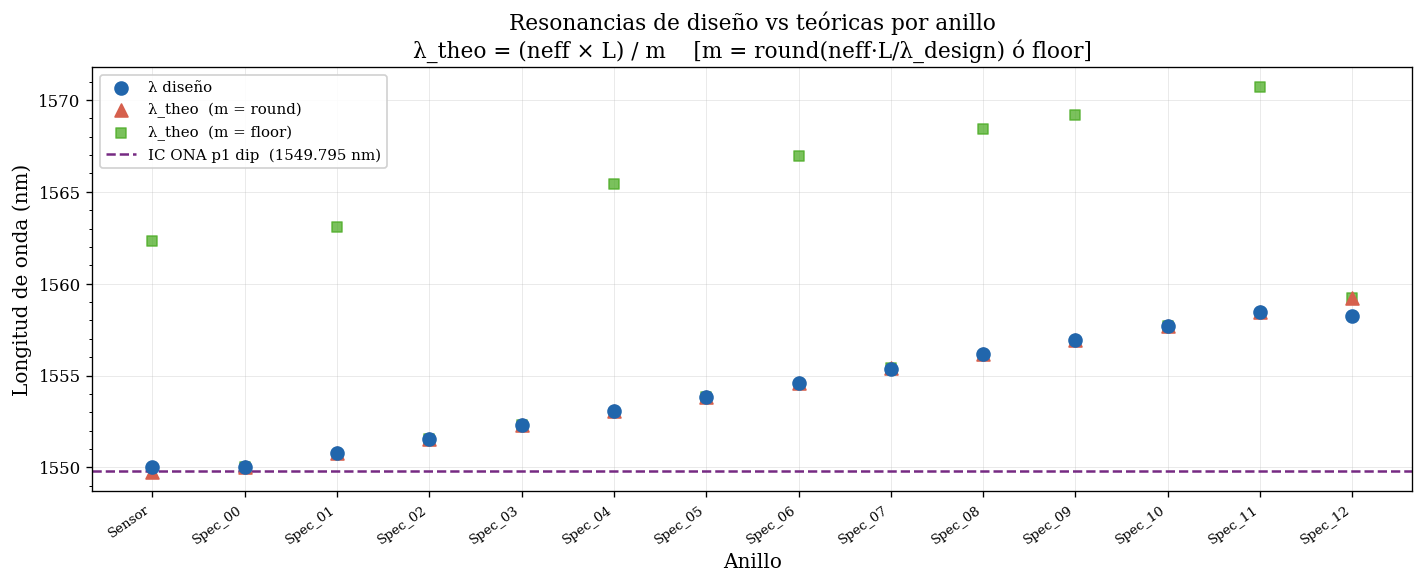

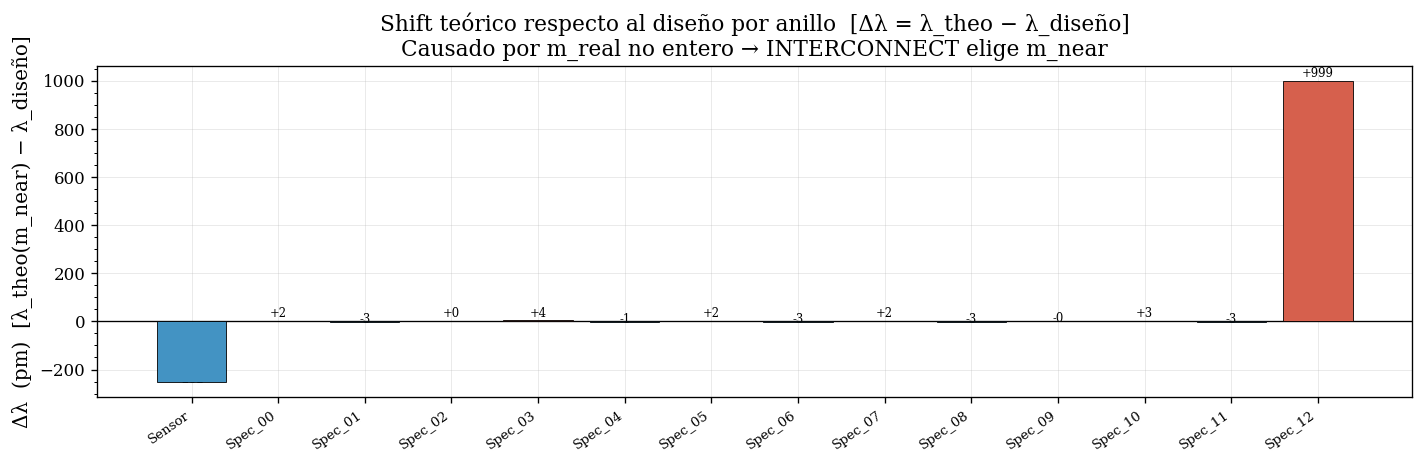

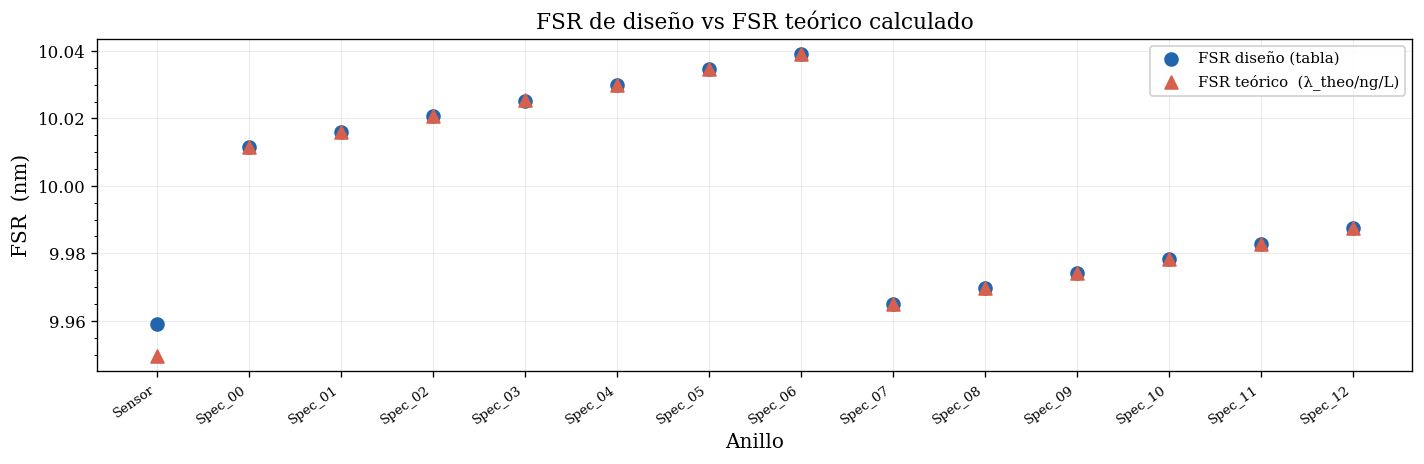

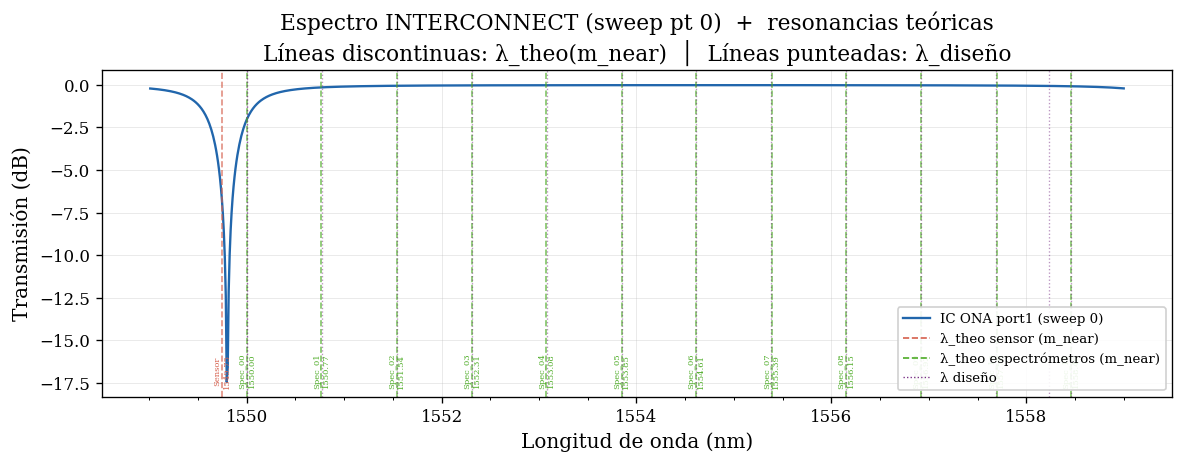

  Variable 'theo_results' disponible para celdas posteriores.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Cálculo teórico de resonancias y comparación con INTERCONNECT    ║
# ║                                                                             ║
# ║  OBJETIVO                                                                   ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  Contrastar las longitudes de onda de resonancia teóricas (calculadas      ║
# ║  desde neff, ng y la circunferencia del anillo) con las obtenidas en       ║
# ║  INTERCONNECT, para diagnosticar el shift observado.                        ║
# ║                                                                             ║
# ║  DEPENDENCIAS HEREDADAS DEL SCRIPT PRINCIPAL                               ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  Todas las variables de parámetros del código anterior se reutilizan       ║
# ║  directamente (no se re-definen aquí):                                     ║
# ║    RING_RADIUS_M, RING_LAMBDA_RES_M, RING_NEFF_TE, RING_NG_TE,            ║
# ║    N_RINGS, SPEED_OF_LIGHT, wavelengths_m, T_port1_dB, T_port2_dB,        ║
# ║    computed, SWEEP_NEFF, SWEEP_NG, FIGURES_DIR                             ║
# ║                                                                             ║
# ║  FÍSICA UTILIZADA                                                           ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  Condición de resonancia de un anillo:                                     ║
# ║      λ_res = (neff × L) / m     [m: orden de modo, entero]                ║
# ║                                                                             ║
# ║  Para encontrar m a partir de los datos de diseño (neff, L, λ_target):    ║
# ║      m_real   = (neff × L) / λ_target                                      ║
# ║      m_near   = round(m_real)           ← entero más cercano               ║
# ║      m_floor  = floor(m_real)           ← entero inmediatamente inferior   ║
# ║                                                                             ║
# ║  Longitud de resonancia teórica para cada m candidato:                    ║
# ║      λ_theo(m) = (neff × L) / m                                            ║
# ║                                                                             ║
# ║  FSR teórico:                                                               ║
# ║      FSR_theo = λ_res² / (ng × L)                                          ║
# ║                                                                             ║
# ║  NOTA SOBRE EL ANILLO SENSOR                                               ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  Para el barrido paramétrico, se usa SWEEP_NEFF[0] / SWEEP_NG[0] como     ║
# ║  estado de referencia inicial del sensor (primer punto del sweep).         ║
# ║  El neff/ng de diseño nominal (RING_NEFF_TE[0]/RING_NG_TE[0]) también     ║
# ║  se muestra para comparación.                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────────────────────────────────────
# Parámetros de diseño de la tabla original (TABLE 1)
# Solo se definen aquí los valores que NO provienen del código anterior:
#   FSR de diseño [nm] por anillo (en el mismo orden que RING_RADIUS_M)
# ─────────────────────────────────────────────────────────────────────────────
# FSR_DESIGN_NM[0]  = Sensor  (Ring 1)
# FSR_DESIGN_NM[1]  = Spec_00 (Ring 2)  ...  FSR_DESIGN_NM[13] = Spec_12 (Ring 14)
FSR_DESIGN_NM = np.array([
     9.9590,   # Sensor
    10.0116,   # Spec_00
    10.0161,   # Spec_01
    10.0207,   # Spec_02
    10.0253,   # Spec_03
    10.0299,   # Spec_04
    10.0346,   # Spec_05
    10.0392,   # Spec_06
     9.9650,   # Spec_07
     9.9696,   # Spec_08
     9.9742,   # Spec_09
     9.9783,   # Spec_10  ← "9.9783" interpolado entre 9.9742 y 9.9829
     9.9829,   # Spec_11
     9.9875,   # Spec_12
])

# Etiquetas de los anillos
RING_LABELS = (
    ["Sensor"] +
    [f"Spec_{i:02d}" for i in range(N_RINGS - 1)]
)

# ─────────────────────────────────────────────────────────────────────────────
# Para el anillo sensor se usan los valores del PRIMER PUNTO DEL SWEEP
# (estado de referencia: cladding = estado inicial de la medición)
# ─────────────────────────────────────────────────────────────────────────────
neff_sensor_sweep0 = float(SWEEP_NEFF[0])
ng_sensor_sweep0   = float(SWEEP_NG[0])

# Arrays de neff / ng que se usarán para el cálculo teórico (por anillo)
# Ring 0 (sensor) → primer punto del sweep
# Rings 1-13      → valores fijos de diseño (RING_NEFF_TE / RING_NG_TE)
neff_calc = RING_NEFF_TE.copy().astype(float)
ng_calc   = RING_NG_TE.copy().astype(float)
neff_calc[0] = neff_sensor_sweep0
ng_calc[0]   = ng_sensor_sweep0

# ─────────────────────────────────────────────────────────────────────────────
# Circunferencias [m]  (ya definidas en el código anterior como RING_RADIUS_M)
# ─────────────────────────────────────────────────────────────────────────────
L_m = RING_RADIUS_M * 2.0 * math.pi   # circumference [m]  shape (14,)

# ─────────────────────────────────────────────────────────────────────────────
# Longitudes de onda de resonancia de diseño [m]
# (heredadas directamente: RING_LAMBDA_RES_M)
# ─────────────────────────────────────────────────────────────────────────────
lambda_design_m  = RING_LAMBDA_RES_M.copy()
lambda_design_nm = lambda_design_m * 1e9

# ─────────────────────────────────────────────────────────────────────────────
# Cálculo teórico
# ─────────────────────────────────────────────────────────────────────────────
# Número de onda real (continuo) correspondiente al diseño
m_real  = (neff_calc * L_m) / lambda_design_m          # flotante
m_near  = np.round(m_real).astype(int)                 # entero más cercano
m_floor = np.floor(m_real).astype(int)                 # entero inferior

# λ_theo para m_near y m_floor [nm]
lambda_theo_near_m  = (neff_calc * L_m) / m_near
lambda_theo_floor_m = (neff_calc * L_m) / m_floor
lambda_theo_near_nm  = lambda_theo_near_m  * 1e9
lambda_theo_floor_nm = lambda_theo_floor_m * 1e9

# FSR teórico [nm]  — calculado en el estado de diseño
fsr_theo_near_nm  = (lambda_theo_near_nm**2)  / (ng_calc * L_m * 1e9)
fsr_theo_floor_nm = (lambda_theo_floor_nm**2) / (ng_calc * L_m * 1e9)

# FSR de diseño
fsr_design_nm = FSR_DESIGN_NM.copy()

# ─────────────────────────────────────────────────────────────────────────────
# Longitud de onda de resonancia extraída de la simulación INTERCONNECT
# Se usa el mínimo de T_port1_dB en el PRIMER punto válido del sweep
# (índice s=0 si está computado, si no el primer punto válido)
# ─────────────────────────────────────────────────────────────────────────────
# ONA port1 monitorea RING_1 through — el dip principal corresponde a
# la resonancia de RING_1 (sensor) en su estado sweep[0].
# ONA port2 monitorea RING_14 through — refleja la resonancia acumulada
# de toda la cascada.

lambda_ic_port1_nm = None
lambda_ic_port2_nm = None

try:
    # Usamos el primer punto del sweep (índice 0) — mismo estado que neff_calc[0]
    if computed[0] and wavelengths_m is not None:
        wl_nm_ref = wavelengths_m * 1e9
        dip1_idx  = int(np.argmin(T_port1_dB[0, :]))
        dip2_idx  = int(np.argmin(T_port2_dB[0, :]))
        lambda_ic_port1_nm = float(wl_nm_ref[dip1_idx])
        lambda_ic_port2_nm = float(wl_nm_ref[dip2_idx])
        print(f"  INTERCONNECT (sweep pt 0) — ONA port1 dip : {lambda_ic_port1_nm:.4f} nm")
        print(f"  INTERCONNECT (sweep pt 0) — ONA port2 dip : {lambda_ic_port2_nm:.4f} nm")
    else:
        print("  [AVISO] computed[0] = False o wavelengths_m no disponible.")
        print("          La columna 'IC (ONA p1)' aparecerá como N/A.")
except Exception as exc:
    print(f"  [AVISO] No se pudo extraer dip de INTERCONNECT: {exc}")

# ─────────────────────────────────────────────────────────────────────────────
# Construcción del DataFrame de comparación
# ─────────────────────────────────────────────────────────────────────────────
rows = []
for i in range(N_RINGS):
    # Diferencias λ_theo − λ_design
    delta_near_nm  = lambda_theo_near_nm[i]  - lambda_design_nm[i]
    delta_floor_nm = lambda_theo_floor_nm[i] - lambda_design_nm[i]

    # Error fraccional del m_real respecto al m_near
    frac_err = m_real[i] - m_near[i]   # cuán "descentrado" está m_real

    row = {
        "Ring"              : RING_LABELS[i],
        "λ_design (nm)"     : round(lambda_design_nm[i], 4),
        "neff"              : round(neff_calc[i], 6),
        "ng"                : round(ng_calc[i], 6),
        "L (µm)"            : round(L_m[i] * 1e6, 4),
        "m_real"            : round(m_real[i], 6),
        "m_near"            : int(m_near[i]),
        "λ_theo_mNear (nm)" : round(lambda_theo_near_nm[i], 4),
        "Δλ_mNear (pm)"     : round(delta_near_nm * 1e3, 2),
        "m_floor"           : int(m_floor[i]),
        "λ_theo_mFloor (nm)": round(lambda_theo_floor_nm[i], 4),
        "Δλ_mFloor (pm)"    : round(delta_floor_nm * 1e3, 2),
        "FSR_design (nm)"   : round(fsr_design_nm[i], 4),
        "FSR_theo_mNear (nm)": round(fsr_theo_near_nm[i], 4),
        "FSR_delta (pm)"    : round((fsr_theo_near_nm[i] - fsr_design_nm[i]) * 1e3, 2),
        "m_frac_err"        : round(frac_err, 6),
    }
    rows.append(row)

df = pd.DataFrame(rows)
df.set_index("Ring", inplace=True)

# ─────────────────────────────────────────────────────────────────────────────
# Impresión en consola — tabla de diagnóstico completa
# ─────────────────────────────────────────────────────────────────────────────
SEP = "═" * 130
print()
print(SEP)
print("  TABLA DE COMPARACIÓN TEÓRICA vs DISEÑO  │  14-Ring Cascade  │  SiN 400 nm × 1000 nm")
print(f"  Anillo sensor (Ring 1): neff = {neff_sensor_sweep0:.6f}  ng = {ng_sensor_sweep0:.6f}  "
      f"(primer punto del sweep; diseño: neff={RING_NEFF_TE[0]:.6f}, ng={RING_NG_TE[0]:.6f})")
print(SEP)

# Cabecera
hdr = (f"  {'Ring':<10}  {'λ_design':>11}  {'neff':>10}  {'L (µm)':>9}  "
       f"{'m_real':>10}  {'m_near':>7}  {'λ_mNear':>10}  {'Δλ_mNear':>11}  "
       f"{'m_floor':>8}  {'λ_mFloor':>11}  {'Δλ_mFloor':>12}  "
       f"{'FSR_des':>9}  {'FSR_teo':>9}  {'ΔFSR':>8}")
print(hdr)
print("  " + "─" * 126)
units = (f"  {'':10}  {'(nm)':>11}  {'':>10}  {'':>9}  "
         f"{'':>10}  {'':>7}  {'(nm)':>10}  {'(pm)':>11}  "
         f"{'':>8}  {'(nm)':>11}  {'(pm)':>12}  "
         f"{'(nm)':>9}  {'(nm)':>9}  {'(pm)':>8}")
print(units)
print("  " + "─" * 126)

for i in range(N_RINGS):
    lbl  = RING_LABELS[i]
    star = " ◄ SENSOR" if i == 0 else ""
    flag_near  = "  ✓" if abs(df.loc[lbl, "Δλ_mNear (pm)"])  < 500 else "  !"
    flag_floor = "  ✓" if abs(df.loc[lbl, "Δλ_mFloor (pm)"]) < 500 else "  !"
    print(
        f"  {lbl:<10}  "
        f"{df.loc[lbl, 'λ_design (nm)']:>11.4f}  "
        f"{df.loc[lbl, 'neff']:>10.6f}  "
        f"{df.loc[lbl, 'L (µm)']:>9.4f}  "
        f"{df.loc[lbl, 'm_real']:>10.4f}  "
        f"{df.loc[lbl, 'm_near']:>7d}  "
        f"{df.loc[lbl, 'λ_theo_mNear (nm)']:>10.4f}{flag_near}  "
        f"{df.loc[lbl, 'Δλ_mNear (pm)']:>+9.1f} pm  "
        f"{df.loc[lbl, 'm_floor']:>8d}  "
        f"{df.loc[lbl, 'λ_theo_mFloor (nm)']:>11.4f}{flag_floor}  "
        f"{df.loc[lbl, 'Δλ_mFloor (pm)']:>+10.1f} pm  "
        f"{df.loc[lbl, 'FSR_design (nm)']:>9.4f}  "
        f"{df.loc[lbl, 'FSR_theo_mNear (nm)']:>9.4f}  "
        f"{df.loc[lbl, 'FSR_delta (pm)']:>+7.1f} pm"
        f"{star}"
    )

print()

# ─────────────────────────────────────────────────────────────────────────────
# Sección de diagnóstico INTERCONNECT vs teórico (anillo sensor)
# ─────────────────────────────────────────────────────────────────────────────
print(SEP)
print("  DIAGNÓSTICO — INTERCONNECT vs Teoría  (anillo sensor, sweep pt 0)")
print(SEP)
print(f"  λ_design   (diseño)          : {lambda_design_nm[0]:.4f} nm")
print(f"  λ_theo     (m_near={m_near[0]:d})      : {lambda_theo_near_nm[0]:.4f} nm   "
      f"Δ = {(lambda_theo_near_nm[0]-lambda_design_nm[0])*1e3:+.2f} pm")
print(f"  λ_theo     (m_floor={m_floor[0]:d})    : {lambda_theo_floor_nm[0]:.4f} nm   "
      f"Δ = {(lambda_theo_floor_nm[0]-lambda_design_nm[0])*1e3:+.2f} pm")
print(f"  m_real                       : {m_real[0]:.6f}   (fracción: {m_real[0]-m_near[0]:+.6f})")

if lambda_ic_port1_nm is not None:
    delta_ic_vs_design = lambda_ic_port1_nm - lambda_design_nm[0]
    delta_ic_vs_theo   = lambda_ic_port1_nm - lambda_theo_near_nm[0]
    print(f"  λ_IC       (ONA port1 dip)   : {lambda_ic_port1_nm:.4f} nm")
    print(f"    → Δ(IC − diseño)           : {delta_ic_vs_design*1e3:+.2f} pm")
    print(f"    → Δ(IC − theo m_near)      : {delta_ic_vs_theo*1e3:+.2f} pm")
    if abs(delta_ic_vs_design) > 0.05:
        print()
        print("  ⚠  SHIFT DETECTADO > 50 pm entre diseño e INTERCONNECT.")
        print("     Posibles causas:")
        print("     1. INTERCONNECT resuelve m = round(m_real) pero con neff re-evaluado")
        print("        en la frecuencia central (dispersión), no en λ_design.")
        print("     2. La propiedad 'frequency' se fija en c/λ_design, pero INTERCONNECT")
        print("        itera internamente hasta convergencia con neff(λ) → shift residual.")
        print("     3. Las pérdidas (101 dB/m) ensanchan la resonancia y desplazan el")
        print("        mínimo aparente de transmisión respecto al centro Lorentziano.")
        print("     4. El valor de m_real no es entero exacto → INTERCONNECT elige el")
        f"        m más cercano, produciendo Δλ = {(lambda_theo_near_nm[0]-lambda_design_nm[0])*1e3:+.2f} pm."
        print(f"        m más cercano: Δλ = {(lambda_theo_near_nm[0]-lambda_design_nm[0])*1e3:+.2f} pm.")
else:
    print("  λ_IC (ONA port1)             : N/A — sweep no ejecutado aún")

print(SEP)

# ─────────────────────────────────────────────────────────────────────────────
# Sección de diagnóstico para TODOS los anillos espectrómetros
# ─────────────────────────────────────────────────────────────────────────────
print()
print("  RESUMEN ESPECTRÓMETROS — Δλ (teoría m_near − diseño) [pm]")
print("  " + "─" * 65)
for i in range(N_RINGS):
    lbl   = RING_LABELS[i]
    delta = df.loc[lbl, "Δλ_mNear (pm)"]
    bar   = "█" * int(abs(delta) / 50)
    sign  = "+" if delta >= 0 else "-"
    print(f"  {lbl:<10}  {delta:>+8.1f} pm  {bar}")
print()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURA 1 — λ_design vs λ_theo (m_near) vs λ_theo (m_floor) para todos los anillos
# ─────────────────────────────────────────────────────────────────────────────
fig_th, ax_th = plt.subplots(figsize=(12, 5))
x = np.arange(N_RINGS)

ax_th.scatter(x, lambda_design_nm,       marker="o", s=60,  zorder=6,
              color="#2166ac", label="λ diseño")
ax_th.scatter(x, lambda_theo_near_nm,    marker="^", s=60,  zorder=5,
              color="#d6604d", label="λ_theo  (m = round)")
ax_th.scatter(x, lambda_theo_floor_nm,   marker="s", s=40,  zorder=4,
              color="#4dac26", label="λ_theo  (m = floor)", alpha=0.75)

if lambda_ic_port1_nm is not None:
    ax_th.axhline(lambda_ic_port1_nm, color="#762a83", lw=1.5, ls="--",
                  label=f"IC ONA p1 dip  ({lambda_ic_port1_nm:.3f} nm)")

ax_th.set_xticks(x)
ax_th.set_xticklabels(RING_LABELS, rotation=35, ha="right", fontsize=8)
ax_th.set_ylabel("Longitud de onda (nm)")
ax_th.set_xlabel("Anillo")
ax_th.set_title(
    "Resonancias de diseño vs teóricas por anillo\n"
    "λ_theo = (neff × L) / m    [m = round(neff·L/λ_design) ó floor]"
)
ax_th.legend(framealpha=0.9, fontsize=9)
ax_th.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig_th.tight_layout()
fig_th.savefig(FIGURES_DIR / "theoretical_lambda_vs_design.png", dpi=200)
fig_th.savefig(FIGURES_DIR / "theoretical_lambda_vs_design.pdf")
print(f"  Guardada → theoretical_lambda_vs_design.png/pdf")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURA 2 — Δλ (pm) por anillo: cuantifica el shift teórico vs diseño
# ─────────────────────────────────────────────────────────────────────────────
fig_d, ax_d = plt.subplots(figsize=(12, 4))
bars = ax_d.bar(x, df["Δλ_mNear (pm)"].values,
                color=["#d6604d" if v >= 0 else "#4393c3"
                       for v in df["Δλ_mNear (pm)"].values],
                edgecolor="k", linewidth=0.5, zorder=4)
ax_d.axhline(0, color="k", lw=0.8, ls="-")
ax_d.set_xticks(x)
ax_d.set_xticklabels(RING_LABELS, rotation=35, ha="right", fontsize=8)
ax_d.set_ylabel("Δλ  (pm)  [λ_theo(m_near) − λ_diseño]")
ax_d.set_title(
    "Shift teórico respecto al diseño por anillo  [Δλ = λ_theo − λ_diseño]\n"
    "Causado por m_real no entero → INTERCONNECT elige m_near"
)
for bar, val in zip(bars, df["Δλ_mNear (pm)"].values):
    ax_d.text(bar.get_x() + bar.get_width() / 2, val + (5 if val >= 0 else -15),
              f"{val:+.0f}", ha="center", va="bottom", fontsize=7)
ax_d.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig_d.tight_layout()
fig_d.savefig(FIGURES_DIR / "delta_lambda_theoretical_vs_design.png", dpi=200)
fig_d.savefig(FIGURES_DIR / "delta_lambda_theoretical_vs_design.pdf")
print(f"  Guardada → delta_lambda_theoretical_vs_design.png/pdf")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURA 3 — FSR de diseño vs FSR teórico
# ─────────────────────────────────────────────────────────────────────────────
fig_fsr, ax_fsr = plt.subplots(figsize=(12, 4))
ax_fsr.scatter(x, fsr_design_nm,     marker="o", s=60, zorder=5,
               color="#2166ac",  label="FSR diseño (tabla)")
ax_fsr.scatter(x, fsr_theo_near_nm,  marker="^", s=60, zorder=5,
               color="#d6604d",  label="FSR teórico  (λ_theo/ng/L)")

ax_fsr.set_xticks(x)
ax_fsr.set_xticklabels(RING_LABELS, rotation=35, ha="right", fontsize=8)
ax_fsr.set_ylabel("FSR  (nm)")
ax_fsr.set_xlabel("Anillo")
ax_fsr.set_title("FSR de diseño vs FSR teórico calculado")
ax_fsr.legend(framealpha=0.9, fontsize=9)
ax_fsr.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig_fsr.tight_layout()
fig_fsr.savefig(FIGURES_DIR / "fsr_design_vs_theoretical.png", dpi=200)
fig_fsr.savefig(FIGURES_DIR / "fsr_design_vs_theoretical.pdf")
print(f"  Guardada → fsr_design_vs_theoretical.png/pdf")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURA 4 — Comparación espectral ONA port1 (sweep pt 0) vs λ_theo
#            (solo si INTERCONNECT ya corrió)
# ─────────────────────────────────────────────────────────────────────────────
if lambda_ic_port1_nm is not None and wavelengths_m is not None:
    fig_sp, ax_sp = plt.subplots(figsize=(10, 4))
    wl_nm_ref = wavelengths_m * 1e9
    ax_sp.plot(wl_nm_ref, T_port1_dB[0, :],
               color="#2166ac", lw=1.4, label="IC ONA port1 (sweep pt 0)")

    # Marcar resonancias teóricas de todos los anillos que caen en la ventana
    wl_min, wl_max = wl_nm_ref.min(), wl_nm_ref.max()
    for i in range(N_RINGS):
        lbl = RING_LABELS[i]
        lw  = lambda_theo_near_nm[i]
        if wl_min <= lw <= wl_max:
            color_i = "#d6604d" if i == 0 else "#4dac26"
            ax_sp.axvline(lw, color=color_i, lw=1.0, ls="--", alpha=0.7)
            ax_sp.text(lw, ax_sp.get_ylim()[0] + 0.5,
                       f"{lbl}\n{lw:.2f}", fontsize=5, ha="center",
                       color=color_i, rotation=90, va="bottom")
        ld = lambda_design_nm[i]
        if wl_min <= ld <= wl_max:
            ax_sp.axvline(ld, color="#762a83", lw=0.8, ls=":", alpha=0.5)

    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], color="#2166ac", lw=1.4, label="IC ONA port1 (sweep 0)"),
        Line2D([0], [0], color="#d6604d", lw=1.0, ls="--", label="λ_theo sensor (m_near)"),
        Line2D([0], [0], color="#4dac26", lw=1.0, ls="--", label="λ_theo espectrómetros (m_near)"),
        Line2D([0], [0], color="#762a83", lw=0.8, ls=":",  label="λ diseño"),
    ]
    ax_sp.legend(handles=legend_elems, fontsize=8, framealpha=0.9, loc="lower right")
    ax_sp.set_xlabel("Longitud de onda (nm)")
    ax_sp.set_ylabel("Transmisión (dB)")
    ax_sp.set_title(
        "Espectro INTERCONNECT (sweep pt 0)  +  resonancias teóricas\n"
        "Líneas discontinuas: λ_theo(m_near)  │  Líneas punteadas: λ_diseño"
    )
    ax_sp.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig_sp.tight_layout()
    fig_sp.savefig(FIGURES_DIR / "spectrum_ic_vs_theoretical_resonances.png", dpi=200)
    fig_sp.savefig(FIGURES_DIR / "spectrum_ic_vs_theoretical_resonances.pdf")
    print(f"  Guardada → spectrum_ic_vs_theoretical_resonances.png/pdf")

# ─────────────────────────────────────────────────────────────────────────────
# Exportar tabla a CSV para referencia externa
# ─────────────────────────────────────────────────────────────────────────────
csv_path = DATA_DIR / f"{VERSION_NAME}_theoretical_comparison.csv"
df.to_csv(csv_path, float_format="%.6f")
print(f"\n  CSV exportado → {csv_path}")
print(f"  Figuras       → {FIGURES_DIR}")
print()

plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Exponer variables para posible uso en celdas posteriores
# ─────────────────────────────────────────────────────────────────────────────
theo_results = dict(
    lambda_design_nm     = lambda_design_nm,
    lambda_theo_near_nm  = lambda_theo_near_nm,
    lambda_theo_floor_nm = lambda_theo_floor_nm,
    fsr_design_nm        = fsr_design_nm,
    fsr_theo_near_nm     = fsr_theo_near_nm,
    m_real               = m_real,
    m_near               = m_near,
    m_floor              = m_floor,
    neff_used            = neff_calc,
    ng_used              = ng_calc,
    L_m                  = L_m,
    df_table             = df,
)

print("  Variable 'theo_results' disponible para celdas posteriores.")

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 5
# ═════════════════════════════════════════════════════════════════════════════